In [1]:
%cd ..
# from experiment_control.srs_microscope.srs_microscope import *
from experiment_control.srs_microscope.plot_srs import *
# %matplotlib widget

c:\Users\Goldfish\Documents\Github\experiment_control


In [2]:
#for running on laptop
from scipy.signal import find_peaks
from scipy.signal import savgol_filter

# calib_dir = os.path.join(home_dir, "experiment_control","calibration_data","VCSEL_calibration")
# data_dir = os.path.join(home_dir,"OneDrive","Documents","data","srs_microscope")

# wavvolt_HVCALIB = os.path.join(calib_dir, "wavvolt_HVCALIB_GSdev1b_delayvolt16_BOA700mA_2025-11-2.mat") #For post-acquisition wavelength calibration
# wavvolt_file = os.path.join(calib_dir, "wavvolt16_dev1b_15C_OE1076_0.00mW_2025-11-1.mat") #For wavelength set
# wavvolt_sweepcal = os.path.join(calib_dir, "wavvolt16_sweepcal.mat") #For post-acquisition wavelength calibration
# wavamp_file = os.path.join(calib_dir, 'wavamp_dev1b_delayvolt16P3_2025-12-09-22-34-51.h5' )


wavvolt_HVCALIB = os.path.join(calib_dir, "wavvolt_HVCALIB_dev1b_15C_OE1076_2025-12-13_delayvolt17.mat") #For post-acquisition wavelength calibration
wavvolt_file = wavvolt_HVCALIB #For wavelength set
wavvolt_sweepcal = wavvolt_file
delayvolt_file =os.path.join(calib_dir, "delayvolt17D.mat")
wavamp_file = os.path.join(calib_dir, 'wavamp_dev1b_delayvolt16P3_2025-12-10-22.h5' )


def plot_daqsweep_wavmon(ds, ds_type='sweep', colors=None, ax=None, fig=None, figsize=(6,4), normalize=True, num_reps=None, peaks_rep=None):
    """
    ds_type: 'sweep': single point daq sweeps, 'hs_im': hyperspectral image
    """
    #Load FFP peaks from calibration file
    fpath = os.path.join(calib_dir,'FFP-I_peaks')
    FFP_cal_pks = load_hdf5(fpath=fpath)
    cal_pks = FFP_cal_pks["peaks"]
    
    
    #restrict FFP_cal_pks to tuning range
    FFP_cal = cal_pks[(cal_pks >= np.nanmin(ds['wavelength_set'])) & (cal_pks <= np.nanmax(ds['wavelength_set']))] 
    FFP_cal = FFP_cal[~((FFP_cal > ds['wavelength_set'][0]) & (FFP_cal < ds['wavelength_set'][-1]))]

    if ds_type == 'sweep':
        wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
        wavset_sort = wavset_sort * u.nm
        wavmon_arr = ds["VCSEL_wavmon_arr"][:, s_ind]
    elif ds_type == 'hs_image':
        wavset_sort = ds["wavset_sort"]
        wavmon_arr = ds["VCSEL_wavmon_pix"]
    else:
        raise ValueError("Specify ds_type='hs_image' or 'sweep'")
    
    if num_reps is None:
        num_reps = wavmon_arr.shape[0]
        
    ylabel = "Volts (V)"   
    if normalize:
        for row in range(num_reps):
            # remove voltage offset
            wavmon_arr[row,:] = wavmon_arr[row,:] - np.min(wavmon_arr[row])
            # normalize to max
            wavmon_arr[row,:] = wavmon_arr[row,:] / np.max(wavmon_arr[row].m)
            ylabel = "Normalized"
            
    #Find peaks
    if peaks_rep is None:
        peaks_rep = 0
    FFP_pks_ind, _ = find_peaks(wavmon_arr[peaks_rep,:], prominence=0.1, height=0.4, distance=10)
    wavmon_pks = wavmon_arr[peaks_rep, FFP_pks_ind]
    
    # plt.plot(np.diff(wavset_sort))
    
    #Plotting  
    if colors is None:
        colors = cm.get_cmap("inferno", num_reps)
        
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=figsize, tight_layout=True)
        
    for row in range(num_reps):
        if row %2 != 0:
            # ax.plot(wavset_sort, wavmon_arr[row], color=odd_color)
            ax.plot(wavset_sort, wavmon_arr[row], color=colors(row))
        else:
            # ax.plot(wavset_sort, wavmon_arr[row], color=even_color)
            ax.plot(wavset_sort, wavmon_arr[row], color=colors(row))
    ax.plot(wavset_sort, wavmon_arr[peaks_rep], color='g')
    ax.plot(wavset_sort[FFP_pks_ind], wavmon_pks, 'x', color='r')
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylabel)
    for wn in FFP_cal.m:
        plt.axvline(wn, color='k', linestyle='--')
    return fig, ax


def plot_daq_sweepSpectra(ds0, savefig=False, fname=None, fpath=None, figsize=(5,6), wavvolt=wavvolt_sweepcal, wavamp_file=wavamp_file, verbose=True, fig=None, ax=None, label=None):
    #First point in sweep already removed in unwrap_sweep()
    HVA_Vset = ds0["HVA_Vset"]
    wavelength_set = ds0["wavelength_set"]
    HV_arr = ds0["HV_arr"]
    raman_shift = ds0["raman_shift"] #sorted in order of increasing voltage

    rs_sort = np.unique(raman_shift.m) / u.cm #sorted by ascending wavelength (ascending raman_shift for tuning Stokes wavelength)

    offset = 0*u.V
    Vsrs_arr = (ds0["Vsrs_arr"] / 10 + offset).to(u.V).m * ds0["sens_lia"].to(u.V)

    Vsrs_interp_arr = calibrate_sweepSpectra(wavelength_set, Vsrs_arr, HVA_Vset, HV_arr=HV_arr, wavvolt=wavvolt, disc_tol=5)
    if wavamp_file is not None:
        Vsrs_interp_arr = correct_amplitude(wavelength_set, Vsrs_interp_arr, HVA_Vset, wavamp_file=wavamp_file)
    # VCSEL_wavmon_arr = ds0["VCSEL_wavmon_arr"]

    Vsrs_av = np.mean(Vsrs_interp_arr, axis=0)
    uncal_Vsrs_av = np.mean(Vsrs_arr, axis=0)
    
    mind = np.nanargmax(Vsrs_av)
    mind_uncal = np.nanargmax(uncal_Vsrs_av)
    
    print("Calib Peak at {:2.3f}".format(rs_sort[mind]))
    print(f"Uncal Peak at {raman_shift[mind_uncal] :2.3f}")

    if ax is None:
        if verbose:
            fig, ax = plt.subplots(3, 1, figsize=figsize, tight_layout=True)
        else:
            fig, ax = plt.subplots(1, 1, figsize=figsize, tight_layout=True)
    
    if verbose:
        for spec in range(Vsrs_arr.shape[0]):
            ax[0].plot(raman_shift, Vsrs_arr[spec].to(u.uV))
            ax[1].plot(rs_sort, Vsrs_interp_arr[spec].to(u.uV))
        
        ax[2].plot(rs_sort, Vsrs_av.to(u.uV))
        ax[2].plot(rs_sort[mind].m, Vsrs_av[mind].to(u.uV).m, 'x')
        # ax[2].plot(raman_shift, np.mean(Vsrs_arr, axis=0).to(u.uV), 'k')
        ax[0].set_ylabel("Voltage $(\mu V)$")
        ax[0].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
        ax[1].set_ylabel("Voltage $(\mu V)$")
        ax[1].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
        ax[2].set_xlabel("Raman Shift (1/cm)")
        ax[2].set_ylabel("Voltage $(\mu V)$")
        ax[2].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    else:
        ax.plot(rs_sort, Vsrs_av.to(u.uV), label=label)
        ax.set_xlabel("Raman Shift (1/cm)")
        ax.set_ylabel("Voltage $(\mu V)$")
        ax.set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    
    if savefig:
        fname=os.path.normpath(os.path.join(fpath,fname))
        plt.savefig(fname, dpi=None, facecolor=None, edgecolor=None,
            orientation='portrait', transparent=True, bbox_inches=None, pad_inches=0.5)
    return fig, ax


def calibrate_sweepSpectra(wavelength_set, Vsrs_arr, HVA_Vset, HV_arr=None, wavvolt=wavvolt_sweepcal, disc_tol=5):
    """
    Calibrate daq VCSEL sweep using HVA monitor.  Return calibrated Vsrs_interp_arr (wavelength interpolated to original wavelength set for consistent
    Raman shifts between iterations)
    wavelength_set: sorted by increasing voltage (same as HV_set) - see parse_wav_delay()
    """
    def line(x,a,b):
        return a*x + b
    
    #sort set wavelength by increasing wavelength ------------------
    wavset_sort = np.unique(wavelength_set.m) * u.nm
    
    dwav = np.mean(np.diff(wavset_sort))
    #-----------------
    
    # Calibrate voltage to wavelength
    a = io.loadmat(wavvolt)
    wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
    volt_calib = a['volt_interp'][0]*u.V
    
    volt_disc_low = volt_calib[np.argmin(wav_calib)]
    volt_disc_hi = volt_calib[np.argmax(wav_calib)]
    
    #determine number of reps
    if Vsrs_arr.ndim > 1:
        num_sweeps = Vsrs_arr.shape[0]
    else:
        num_sweeps = 1
    
    if HV_arr is not None:
        print(f"Calibrating from HV mon")
        
        # Initialize arrays
        HV_filt = np.array(np.zeros(Vsrs_arr.shape))
        wav_calib_arr = np.array(np.zeros(Vsrs_arr.shape))
        wav_calib_sort = np.array(np.zeros(Vsrs_arr.shape))
        Vsrs_interp_arr = np.array(np.zeros((num_sweeps, wavset_sort.shape[0])))
        Vsrs_arr_sort = np.array(np.zeros(Vsrs_arr.shape))
        
        for spec in range(HV_arr.shape[0]):
            popt,_ = curve_fit(line, HVA_Vset.to(u.V).m, HV_arr[spec].to(u.V).m)
            HV_filt[spec] = line(HVA_Vset.m, popt[0], popt[1])
        HV_filt = HV_filt*u.V 
    
        # Find wavelengths corresponding to measured voltage 
        # fig, ax = plt.subplots(2,1)
        if num_sweeps > 1:
            for sweep_iter in range(num_sweeps):
                for wl in range(HV_filt.shape[1]):
                    ind = np.nanargmin(np.abs(HV_filt[sweep_iter, wl].m - volt_calib.m))
                    wav_calib_arr[sweep_iter, wl] = wav_calib[ind].m
                    
                #sort extracted wavelength from HV mon by increasing wavelength
                wlsort_ind = np.argsort(wav_calib_arr[sweep_iter])
                
                wav_calib_sort[sweep_iter] = wav_calib_arr[sweep_iter, wlsort_ind]
                Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
                
                # Interpolate wavelength vs spectra to uniformly sample in wavelength
                Vsrs_interp_arr[sweep_iter,:] = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort[sweep_iter,:], Vsrs_arr_sort[sweep_iter,:])

                # Remove discontinuity
                if np.max(np.diff(wavset_sort.m)) > dwav.to(u.nm).m * disc_tol:
                    bad_ind = np.where(np.diff(wavset_sort.m) > dwav.to(u.nm).m * disc_tol)# | np.diff(wavset_sort.m) == 0)
                    bad_ind2 = np.where(np.diff(wavset_sort.m) == 0)
                    Vsrs_interp_arr[sweep_iter, bad_ind] = np.nan
                    Vsrs_interp_arr[sweep_iter, bad_ind2] = np.nan
        else: #single rep
            for wl in range(HV_filt.shape[1]):
                ind = np.nanargmin(np.abs(HV_filt[wl].m - volt_calib.m))
                wav_calib_arr[wl] = wav_calib[ind].m
                
            #sort extracted wavelength from HV mon by increasing wavelength
            wlsort_ind = np.argsort(wav_calib_arr)
            
            wav_calib_sort = wav_calib_arr[wlsort_ind]
            Vsrs_arr_sort = Vsrs_arr[wlsort_ind]
            
            # Interpolate wavelength vs spectra to uniformly sample in wavelength
            Vsrs_interp_arr = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort, Vsrs_arr_sort)

            # Remove discontinuity
            if np.max(np.diff(wavset_sort)) > dwav.to(u.nm).m * disc_tol:
                bad_ind = np.where(np.diff(wavset_sort) > dwav.to(u.nm).m * disc_tol)# | np.diff(wavset_sort[,:]) == 0)
                bad_ind2 = np.where(np.diff(wavset_sort) == 0)
                Vsrs_interp_arr[bad_ind] = np.nan
                Vsrs_interp_arr[bad_ind2] = np.nan
                    
    else: #if no HV_arr (HVA mon) provided, calibrate to wavvolt_sweepcal instead
        print(f"Calibrating from wavvolt_sweepcal")
        
        # Initialize arrays
        HV_filt = np.array(np.zeros(HVA_Vset.shape))
        wav_calib_arr = np.array(np.zeros(HVA_Vset.shape))
        wav_calib_sort = np.array(np.zeros(HVA_Vset.shape))
        Vsrs_interp_arr = np.array(np.zeros((num_sweeps, wavset_sort.shape[0])))
        Vsrs_arr_sort = np.array(np.zeros(Vsrs_arr.shape))
        
        for i in range(HVA_Vset.shape[0]):
            ind = np.nanargmin(np.abs(HVA_Vset[i].m - volt_calib.m))
            wav_calib_arr[i] = wav_calib[ind].m
        
        #sort extracted wavelength from HV mon by increasing wavelength
        wlsort_ind = np.argsort(wav_calib_arr)
        wav_calib_sort = wav_calib_arr[wlsort_ind]
        
        if num_sweeps > 1:
            for sweep_iter in range(num_sweeps):
                Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
            
                # Interpolate wavelength vs spectra to uniformly sample in wavelength
                Vsrs_interp_arr[sweep_iter,:] = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort, Vsrs_arr_sort[sweep_iter,:])
        else:
            Vsrs_arr_sort = Vsrs_arr[wlsort_ind]
        
            # Interpolate wavelength vs spectra to uniformly sample in wavelength
            Vsrs_interp_arr = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort, Vsrs_arr_sort)

        # Remove discontinuity
    #    if (HVA_Vset[i] >= volt_disc_low) and (HVA_Vset[i] <= volt_disc_hi): #In discontinuity zone
                
    #         else:
        if np.max(np.diff(wavset_sort)) > dwav.to(u.nm).m * disc_tol:
            bad_ind = np.where(np.diff(wavset_sort) > dwav.to(u.nm).m * disc_tol)# | np.diff(wavset_sort[sweep_iter,:]) == 0)
            bad_ind2 = np.where(np.diff(wavset_sort) == 0)
            Vsrs_interp_arr[:, bad_ind] = np.nan
            Vsrs_interp_arr[:, bad_ind2] = np.nan
                
    return Vsrs_interp_arr*u.V


def correct_amplitude(wavelength_set, Vsrs_interp_arr, HVA_Vset, wavamp_file=wavamp_file):
    #Correct Vsrs_interp_arr (wavelength-corrected Vsrs_arr) for intensity variations from wavelength-dependent VCSEL power
    #wavamp_file based on FFP tap
    #wavamp_file["wavelength"], wavamp_file["amplitude_scale"]
    a = load_hdf5(wavamp_file)
    wavelength_wavamp =  a['wavelength']
    amplitude_scale = a['amplitude_scale']
    
    # Sort by increasing wavelength (wavelength_set sorted by increasing voltage)
    wavset_sort, s_ind = np.unique(wavelength_set.to(u.nm).m, return_index=True)
    wavset_sort = wavset_sort * u.nm
    
    # Map amplitude_scale to wavset_sort using wavamp_file
    wset_ampscale = np.zeros(wavset_sort.shape)
    for i, wav in enumerate(wavset_sort):
        ind = np.argmin(np.abs(wav - wavelength_wavamp))
        wset_ampscale[i] = amplitude_scale[ind]
        
    # Scale Vsrs_interp_arr (already sorted by wavelength)
    Vsrs_corr = Vsrs_interp_arr / wset_ampscale

    return Vsrs_corr


def calibrate_hyperspectral_scan(ds, Vsrs_hs: xr.DataArray, sgolay_len=10, sgolay_order=4, wavvolt_file=wavvolt_file, wavvolt_cal=wavvolt_sweepcal, wavamp_file=wavamp_file):
    """
    Smooth, wavelength calibrate, and amplitude correct HS image data
    Return: Vsrs_proc_hs: processed xarray
    """

    # Vsrs_2d = np.asarray(Vsrs_hs.sel(raman_shift=wavnum, method="nearest")) 
    # Vsrs_2d = (Vsrs_2d / 10 + offset).to(u.V).m * ds["sens_lia"].to(u.V).m
    a = io.loadmat(wavvolt_file)
    wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
    volt_calib = a['volt_interp'][0]*u.V
   
    wavelength_set = ds["wavset_sort"].to(u.nm)
    HVA_Vset = np.zeros(wavelength_set.shape)
    for i, wav in enumerate(wavelength_set):
        ind = np.argmin(np.abs(wav_calib.m - wav.m))
        HVA_Vset[i] = volt_calib[ind].m
    HVA_Vset = HVA_Vset * u.V
    HV_arr = ds["HV_arr"]

    Vsrs_proc = np.zeros(Vsrs_hs.shape)
    
    for x_ind in range(Vsrs_hs.sizes['x']):
        for y_ind in range(Vsrs_hs.sizes['y']):
            pix_spec = Vsrs_hs.isel(x=x_ind, y=y_ind)
            #smooth
            pix_spec_smooth = savgol_filter(pix_spec, window_length=sgolay_len, polyorder=sgolay_order)
            #wavelength correction
            # pix_spec_cal = calibrate_sweepSpectra(wavelength_set, pix_spec_smooth, HVA_Vset, HV_arr=None, wavvolt=wavvolt_cal, disc_tol=5)
            pix_spec_cal = calibrate_sweepSpectra(wavelength_set, pix_spec_smooth, HVA_Vset, HV_arr, wavvolt=wavvolt_cal, disc_tol=5)
            #amplitude correction
            pix_spec_cor = correct_amplitude(wavelength_set, pix_spec_cal, HVA_Vset, wavamp_file=wavamp_file)
            #Store processed data into array
            Vsrs_proc[x_ind, y_ind, :] = pix_spec_cor
    
    # Convert to xarray dataarray
    Vsrs_proc_hs = hs_xarray(data=Vsrs_proc, x=np.asarray(Vsrs_hs['x']), y=np.asarray(Vsrs_hs['y'], raman_shift=np.asarray([Vsrs_hs['raman_shift']])))
            
    return Vsrs_proc_hs

# fig, ax = plot_daqsweep_wavmon(ds, ds_type='sweep', figsize=(18,4), num_reps=None, peaks_rep=-2, normalize=False)
# ax.set_xlim((1250, 1350))
# plt.show()



<>:128: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:133: SyntaxWarning: invalid escape sequence '\m'
<>:138: SyntaxWarning: invalid escape sequence '\m'
<>:128: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:133: SyntaxWarning: invalid escape sequence '\m'
<>:138: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_20120\889526481.py:128: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Voltage $(\mu V)$")
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_20120\889526481.py:130: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Voltage $(\mu V)$")
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_20120\889526481.py:133: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_ylabel("Voltage $(\mu V)$")
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_20120\889526481.py:138: SyntaxWarning: invalid escape sequence '\m'
  ax

# Plot Galvo scan

In [37]:
d_spot = 0.9*u.um
N = 150
Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
print(np.max(ds0['x']) - np.min(ds0['x']))
print((np.max(ds0['x']) - np.min(ds0['x']))/N)
print(np.max(ds0['t']))


scan volt: 0.3872813366541991 volt
scan length: 67.5 micrometer
75.0 micrometer
0.5 micrometer
11.25 second


loading file: GalvoScan_tomatoFruit_BOA_1074.5_10ms100uV_N100_74mW_step0.66_scan66um_1283nm_2025-12-17-16-12-05.h5
importing Dev1...
importing Vsrs_g...
importing Vx...
importing Vy...
importing laser_spot_img...
importing t...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...


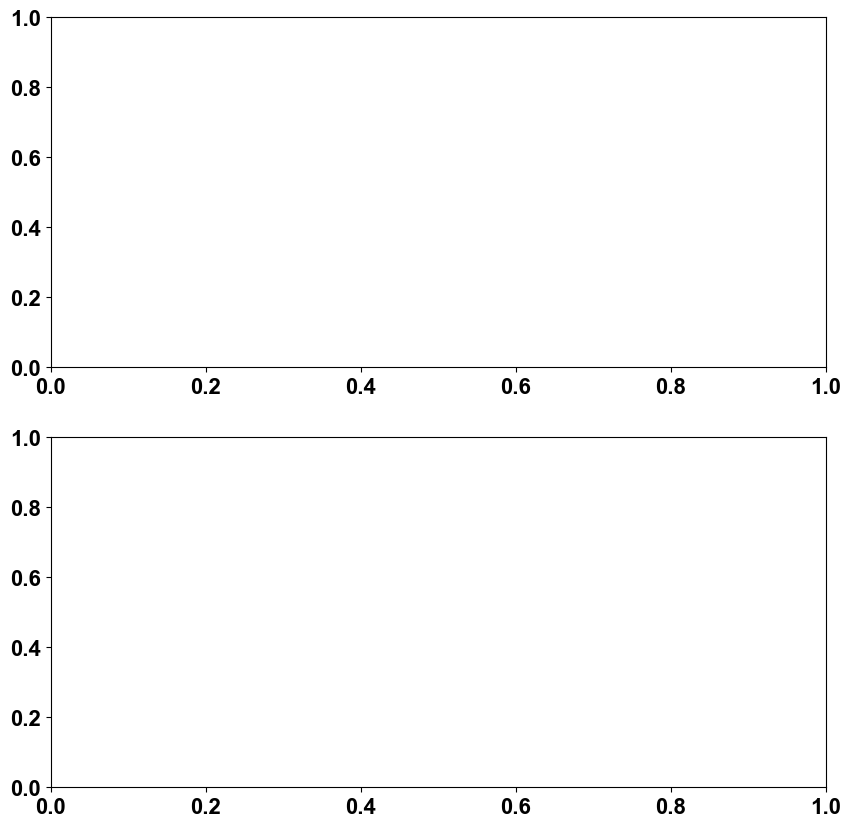

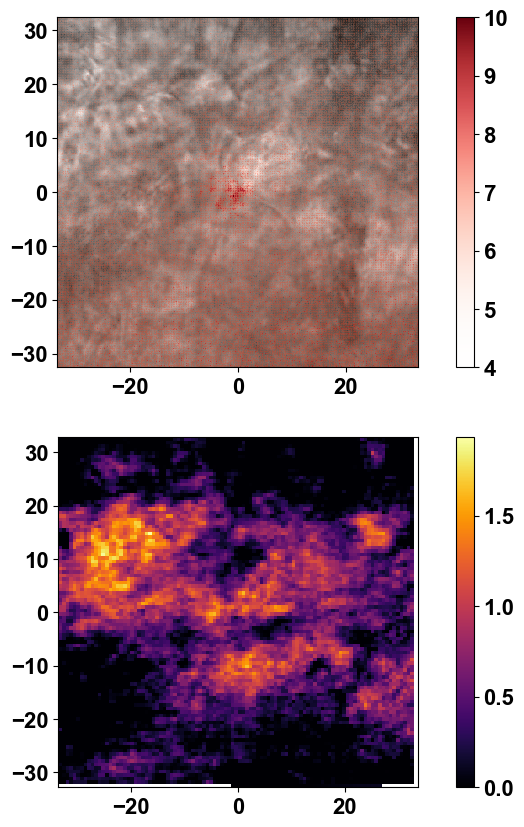

In [97]:
fname = "GalvoScan_tomatoFruit_BOA_1074.5_10ms100uV_N100_74mW_step0.66_scan66um_1283nm_2025-12-17-16-12-05.h5"
dir_name =  "Sample_GSdev1b_Olympus30x_delayvolt17D_BOA_RandomPlants_2025-12-17-14-07-54"

fpath=os.path.join(data_dir, "PROCESS", dir_name)
ds0=load_data_from_file(fpath, fname)

%matplotlib inline
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=None)

# Plot Single Point spectrum

Calibrating from HV mon
loading file: wavamp_dev1b_delayvolt16P3_2025-12-09-22-34-51.h5
importing amplitude_scale...
importing wavelength...
Calib Peak at 1530.123 / centimeter
Uncal Peak at 1532.657 / centimeter


C:\Users\euyehara\AppData\Local\Temp\ipykernel_18004\3598540380.py:193: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]


Calibrating from wavvolt_sweepcal
loading file: wavamp_dev1b_delayvolt16P3_2025-12-09-22-34-51.h5
importing amplitude_scale...
importing wavelength...
Calib Peak at 1533.783 / centimeter
Uncal Peak at 1532.657 / centimeter


C:\Users\euyehara\AppData\Local\Temp\ipykernel_18004\3598540380.py:224: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]


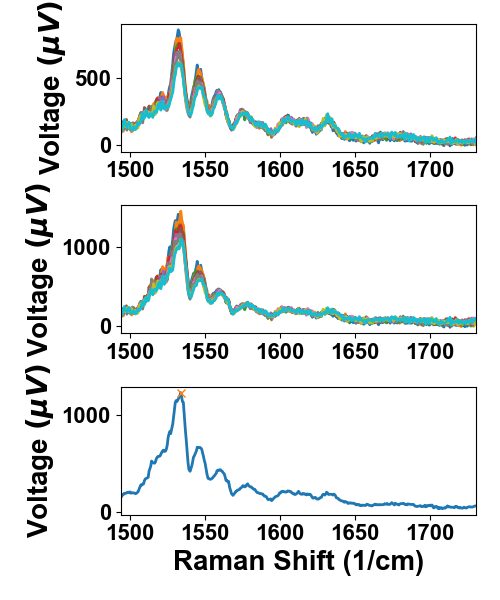

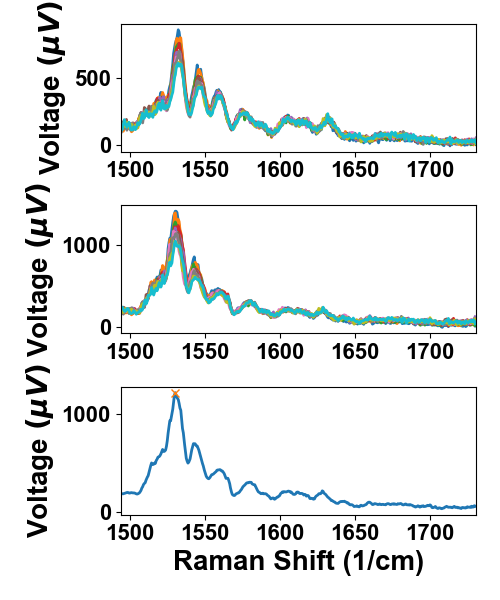

In [47]:

savepath = None
fname = None
fig = plot_daq_sweepSpectra(ds0, wavvolt=wavvolt_HVCALIB, wavamp_file=wavamp_file)
fig = plot_daq_sweepSpectra(ds0, wavvolt=wavvolt_sweepcal, wavamp_file=wavamp_file)
plt.show()

# Compare multiple spectra

loading file: Spectra_UHFLI_step0.1nm_100us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-03-28.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing Vsrs_θ...
importing Vsrs_θ_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
microsecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
loading file: Spectra_UHFLI_step0.1nm_50us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-12-12.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset

C:\Users\Goldfish\AppData\Local\Temp\ipykernel_24320\889526481.py:204: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]


Calib Peak at 1483.028 / centimeter
Uncal Peak at 1505.261 / centimeter
Calibrating from HV mon


c:\Users\Goldfish\miniforge3\envs\tidy3d\Lib\site-packages\matplotlib\cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


Calib Peak at 1505.261 / centimeter
Uncal Peak at 1507.081 / centimeter
Calibrating from HV mon
Calib Peak at 1511.627 / centimeter
Uncal Peak at 1508.445 / centimeter
Calibrating from HV mon
Calib Peak at 1509.809 / centimeter
Uncal Peak at 1509.809 / centimeter
Calibrating from HV mon
Calib Peak at 1513.444 / centimeter
Uncal Peak at 1513.444 / centimeter
Calibrating from HV mon
Calib Peak at 1509.809 / centimeter
Uncal Peak at 1510.264 / centimeter
Calibrating from HV mon
Calib Peak at 1512.082 / centimeter
Uncal Peak at 1512.082 / centimeter


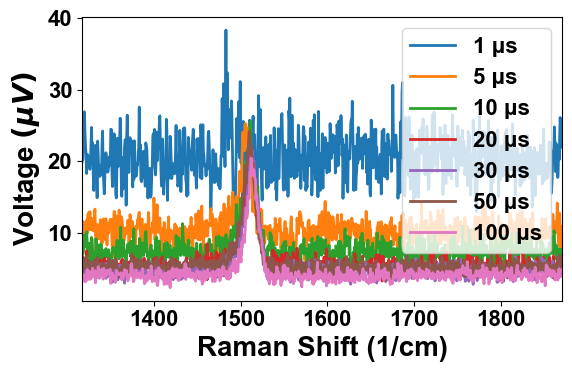

In [ ]:
fpath = os.path.join(data_dir,"PROCESS","Sample_GSdev1b_Olympus30x_delayvolt17D_BOA_Bcarot_neoxanthin_2025-12-14-00-18-57")
fname = "Spectra_UHFLI_step0.1nm_100us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-03-28.h5"
ds0 = load_data_from_file(fpath, fname)

fname1 = "Spectra_UHFLI_step0.1nm_50us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-12-12.h5"
ds1 = load_data_from_file(fpath, fname1)

fname2 = "Spectra_UHFLI_step0.1nm_30us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-08-00.h5"
ds2 = load_data_from_file(fpath, fname2)

fname3 = "Spectra_UHFLI_step0.1nm_20us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-08-45.h5"
ds3 = load_data_from_file(fpath, fname3)

fname4 = "Spectra_UHFLI_step0.1nm_10us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-09-24.h5"
ds4 = load_data_from_file(fpath, fname4)

fname5 = "Spectra_UHFLI_step0.1nm_5us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-10-07.h5"
ds5 = load_data_from_file(fpath, fname5)

fname6 = "Spectra_UHFLI_step0.1nm_1us1mV_5tlia_10reps_40dB_71W_2025-12-14-23-10-44.h5"
ds6 = load_data_from_file(fpath, fname6)


fig, ax = plot_daq_sweepSpectra(ds6, wavvolt=wavvolt_sweepcal, wavamp_file=None, verbose=False, figsize=(6,4), label='1 μs')
fig, ax = plot_daq_sweepSpectra(ds5, wavvolt=wavvolt_sweepcal, wavamp_file=None, verbose=False, figsize=(6,4), label='5 μs', fig=fig, ax=ax)
fig, ax = plot_daq_sweepSpectra(ds4, wavvolt=wavvolt_sweepcal, wavamp_file=None, verbose=False, figsize=(6,4), label='10 μs', fig=fig, ax=ax)
fig, ax = plot_daq_sweepSpectra(ds3, wavvolt=wavvolt_sweepcal, wavamp_file=None, verbose=False, figsize=(6,4), label='20 μs', fig=fig, ax=ax)
fig, ax = plot_daq_sweepSpectra(ds2, wavvolt=wavvolt_sweepcal, wavamp_file=None, verbose=False, figsize=(6,4), label='30 μs', fig=fig, ax=ax)
fig, ax = plot_daq_sweepSpectra(ds1, wavvolt=wavvolt_sweepcal, wavamp_file=None, verbose=False, figsize=(6,4), label='50 μs', fig=fig, ax=ax)
fig, ax = plot_daq_sweepSpectra(ds0, wavvolt=wavvolt_sweepcal, wavamp_file=None, verbose=False, figsize=(6,4), label='100 μs', fig=fig, ax=ax) 
ax.legend(loc='upper right')
plt.show()

# Plot Raw Hyperspectral Image

In [5]:
%matplotlib inline

In [15]:
d_spot = 1.8*u.um
N = 150
Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot, scale=2.3)
print(np.max(ds['x']) - np.min(ds['x']))
print((np.max(ds['x']) - np.min(ds['x']))/N)
# print(np.max(ds0['t']))

scan volt: 0.6735327593986071 volt
scan length: 117.3913043478261 micrometer
step size: 0.782608695652174 micrometer
117.3913043478261 micrometer
0.782608695652174 micrometer


loading file: HyperspecImg_N100_acetamCaff_0.5nm_30ms30uV_512min_5tlia_scan112.5um_step2.25um_75mW_2025-12-16-16-30-55.h5
importing Dev1...
importing Dev2...
importing HV_g...
importing HV_pix...
importing VCSEL_wavmon_g...
importing VCSEL_wavmon_pix...
importing Vsrs_g...
importing Vsrs_pix...
importing Vsrs_θ_g...
importing Vsrs_θ_pix...
importing Vx...
importing Vy...
importing laser_spot_img...
importing raman_shift...
importing t...
importing t_scan...
importing t_sweep...
importing wavelength_set...
importing wavset_sort...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...
importing attr num_sweep...
importing attr pump_w

c:\Users\Goldfish\miniforge3\envs\tidy3d\Lib\site-packages\matplotlib\cbook.py:684: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


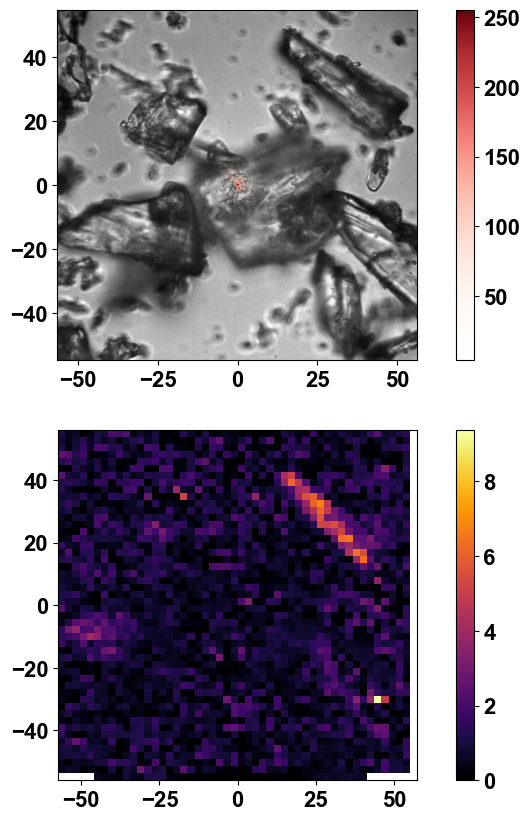

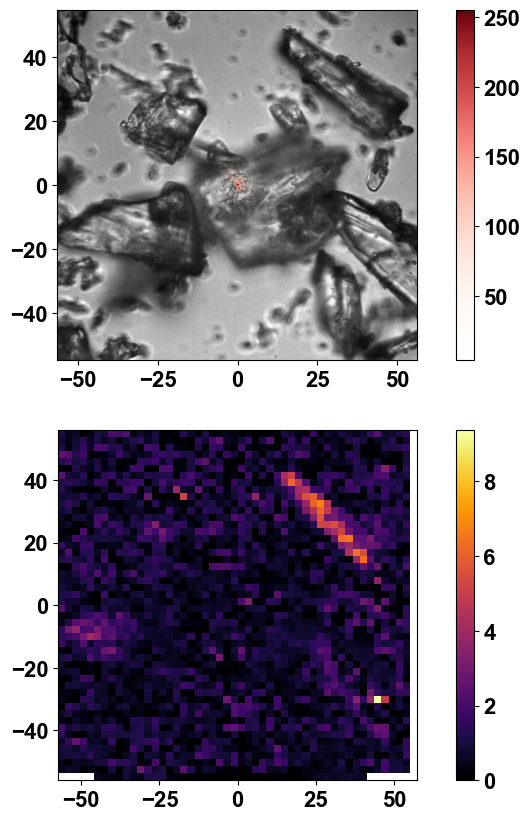

In [8]:
# fpath = os.path.join(data_dir, "Sample_GSdev1b_PDFA_Olypmus30x_hyperspectral_image_Bcarotene_Neoxanthin_2025-12-10-19-45-30")
# fname = "HyperspecImg_N200_neox_bcarot_0.3nm_300us3mV_136min_5tlia_scale2.2dspot1.8um_74mW_2025-12-10-20-39-02"

fpath = os.path.join(data_dir, "PROCESS","Sample_GSdev1b_BOA_Olypmus30x_HSim_acetaminophenCaffeine_delayvol17_2025-12-16-16-29-48")
fname = "HyperspecImg_N100_acetamCaff_0.5nm_30ms30uV_512min_5tlia_scan112.5um_step2.25um_75mW_2025-12-16-16-30-55"
ds = load_data_from_file(fpath, fname + ".h5")
Vsrs_hs = xr.open_dataarray(os.path.join(fpath, fname + ".nc"))
%matplotlib inline
wavnum = 1634 / u.cm
fig = plot_hyperspectral_scan(ds, Vsrs_hs, wavnum, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=None, wf_offsets=None, plot_wf=True)
# plt.show()

Peak at 1634.8950773836993 1/cm


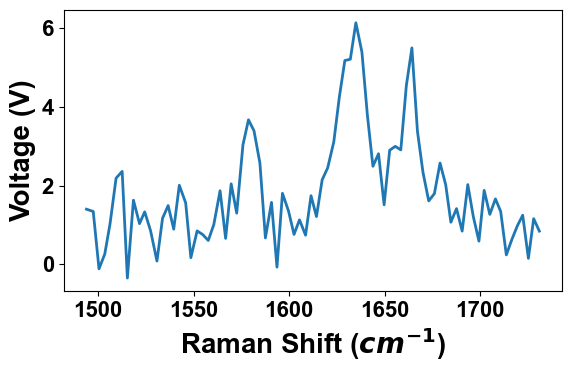

In [11]:
%matplotlib inline
# #N100
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-6, y=-3)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-37, y=-39, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=7, y=23, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=1.6, y=1.5, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=25, y=8, ax=ax, fig=fig)

# #N210
# fig, ax = plot_pixel_spec(Vsrs_hs, x=16, y=-9)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-60, y=21, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=50, y=50, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=38, y=35, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=11, y=62, ax=ax, fig=fig)

# N200
# fig, ax = plot_pixel_spec(Vsrs_hs, x=16, y=-9)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=39, y=35, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=50, y=50, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=38, y=35, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=11, y=62, ax=ax, fig=fig)

#BOA N100 - 2025-12-11-23
# fig, ax = plot_pixel_spec(Vsrs_hs, x=5, y=19)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=9, y=30, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=29, y=-12, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-28, y=24, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-5, y=5, ax=ax, fig=fig)

#BOA N100 - 2025-12-14-17
# fig, ax = plot_pixel_spec(Vsrs_hs, x=19, y=6)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=18, y=42, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-18, y=5, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=34, y=25, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-34, y=31, ax=ax, fig=fig)

#BOA N100 - 2025-12-14-14
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-10, y=28)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-14, y=7, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-49, y=4, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=36, y=-24, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=40, y=40, ax=ax, fig=fig)

#BOA N100 - 2025-12-14-18
# fig, ax = plot_pixel_spec(Vsrs_hs, x=9, y=14)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-14, y=14, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=34, y=26, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=19, y=5, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-41, y=-35.3, ax=ax, fig=fig)

#BOA N230 - 2025-12-14-19
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-30, y=0)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=17, y=-18, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-54, y=50, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=35, y=58, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=19, y=5, ax=ax, fig=fig)

#BOA N230 - 2025-12-14-23
fig, ax = plot_pixel_spec(Vsrs_hs, x=26, y=31)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=20, y=0, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-29, y=24, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=36, y=-32, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=3, y=16, ax=ax, fig=fig)
plt.show()

In [185]:
def calibrate_sweepSpectra(wavelength_set, Vsrs_arr, HVA_Vset, HV_arr=None, wavvolt=wavvolt_sweepcal, disc_tol=5):
    """
    Calibrate daq VCSEL sweep using HVA monitor.  Return calibrated Vsrs_interp_arr (wavelength interpolated to original wavelength set for consistent
    Raman shifts between iterations)
    wavelength_set: sorted by increasing voltage (same as HV_set) - see parse_wav_delay()
    """
    def line(x,a,b):
        return a*x + b
    
    #sort set wavelength by increasing wavelength ------------------
    wavset_sort = np.unique(wavelength_set.m) * u.nm
    
    dwav = np.mean(np.diff(wavset_sort))
    #-----------------
    
    # Calibrate voltage to wavelength
    a = io.loadmat(wavvolt)
    wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
    volt_calib = a['volt_interp'][0]*u.V
    
    volt_disc_low = volt_calib[np.argmin(wav_calib)]
    volt_disc_hi = volt_calib[np.argmax(wav_calib)]
    
    #determine number of reps
    if Vsrs_arr.ndim > 1:
        num_sweeps = Vsrs_arr.shape[0]
    else:
        num_sweeps = 1
    
    if HV_arr is not None:
        print(f"Calibrating from HV mon")
        
        # Initialize arrays
        HV_filt = np.array(np.zeros(Vsrs_arr.shape))
        wav_calib_arr = np.array(np.zeros(Vsrs_arr.shape))
        wav_calib_sort = np.array(np.zeros(Vsrs_arr.shape))
        Vsrs_interp_arr = np.array(np.zeros((num_sweeps, wavset_sort.shape[0])))
        Vsrs_arr_sort = np.array(np.zeros(Vsrs_arr.shape))
        
        for spec in range(HV_arr.shape[0]):
            popt,_ = curve_fit(line, HVA_Vset.to(u.V).m, HV_arr[spec].to(u.V).m)
            HV_filt[spec] = line(HVA_Vset.m, popt[0], popt[1])
        HV_filt = HV_filt*u.V 
    
        # Find wavelengths corresponding to measured voltage 
        # fig, ax = plt.subplots(2,1)
        if num_sweeps > 1:
            for sweep_iter in range(num_sweeps):
                for wl in range(HV_filt.shape[1]):
                    ind = np.nanargmin(np.abs(HV_filt[sweep_iter, wl].m - volt_calib.m))
                    wav_calib_arr[sweep_iter, wl] = wav_calib[ind].m
                    
                #sort extracted wavelength from HV mon by increasing wavelength
                wlsort_ind = np.argsort(wav_calib_arr[sweep_iter])
                
                wav_calib_sort[sweep_iter] = wav_calib_arr[sweep_iter, wlsort_ind]
                Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
                
                # Interpolate wavelength vs spectra to uniformly sample in wavelength
                Vsrs_interp_arr[sweep_iter,:] = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort[sweep_iter,:], Vsrs_arr_sort[sweep_iter,:])

                # Remove discontinuity
                if np.max(np.diff(wavset_sort.m)) > dwav.to(u.nm).m * disc_tol:
                    bad_ind = np.where(np.diff(wavset_sort.m) > dwav.to(u.nm).m * disc_tol)# | np.diff(wavset_sort.m) == 0)
                    bad_ind2 = np.where(np.diff(wavset_sort.m) == 0)
                    Vsrs_interp_arr[sweep_iter, bad_ind] = np.nan
                    Vsrs_interp_arr[sweep_iter, bad_ind2] = np.nan
        else: #single rep
            for wl in range(HV_filt.shape[1]):
                ind = np.nanargmin(np.abs(HV_filt[wl].m - volt_calib.m))
                wav_calib_arr[wl] = wav_calib[ind].m
                
            #sort extracted wavelength from HV mon by increasing wavelength
            wlsort_ind = np.argsort(wav_calib_arr)
            
            wav_calib_sort = wav_calib_arr[wlsort_ind]
            Vsrs_arr_sort = Vsrs_arr[wlsort_ind]
            
            # Interpolate wavelength vs spectra to uniformly sample in wavelength
            Vsrs_interp_arr = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort, Vsrs_arr_sort)

            # Remove discontinuity
            if np.max(np.diff(wavset_sort)) > dwav.to(u.nm).m * disc_tol:
                bad_ind = np.where(np.diff(wavset_sort) > dwav.to(u.nm).m * disc_tol)# | np.diff(wavset_sort[,:]) == 0)
                bad_ind2 = np.where(np.diff(wavset_sort) == 0)
                Vsrs_interp_arr[bad_ind] = np.nan
                Vsrs_interp_arr[bad_ind2] = np.nan
                    
    else: #if no HV_arr (HVA mon) provided, calibrate to wavvolt_sweepcal instead
        print(f"Calibrating from wavvolt_sweepcal")
        
        # Initialize arrays
        HV_filt = np.array(np.zeros(HVA_Vset.shape))
        wav_calib_arr = np.array(np.zeros(HVA_Vset.shape))
        wav_calib_sort = np.array(np.zeros(HVA_Vset.shape))
        Vsrs_interp_arr = np.array(np.zeros((num_sweeps, wavset_sort.shape[0])))
        Vsrs_arr_sort = np.array(np.zeros(Vsrs_arr.shape))
        
        for i in range(HVA_Vset.shape[0]):
            ind = np.nanargmin(np.abs(HVA_Vset[i].m - volt_calib.m))
            wav_calib_arr[i] = wav_calib[ind].m
        
        #sort extracted wavelength from HV mon by increasing wavelength
        wlsort_ind = np.argsort(wav_calib_arr)
        wav_calib_sort = wav_calib_arr[wlsort_ind]
        
        if num_sweeps > 1:
            for sweep_iter in range(num_sweeps):
                Vsrs_arr_sort[sweep_iter] = Vsrs_arr[sweep_iter, wlsort_ind]
            
                # Interpolate wavelength vs spectra to uniformly sample in wavelength
                Vsrs_interp_arr[sweep_iter,:] = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort, Vsrs_arr_sort[sweep_iter,:])
        else:
            Vsrs_arr_sort = Vsrs_arr[wlsort_ind]
        
            # Interpolate wavelength vs spectra to uniformly sample in wavelength
            Vsrs_interp_arr = np.interp(wavset_sort.to(u.nm).m, wav_calib_sort, Vsrs_arr_sort)

        # Remove discontinuity
    #    if (HVA_Vset[i] >= volt_disc_low) and (HVA_Vset[i] <= volt_disc_hi): #In discontinuity zone
                
    #         else:
        if np.max(np.diff(wavset_sort)) > dwav.to(u.nm).m * disc_tol:
            bad_ind = np.where(np.diff(wavset_sort) > dwav.to(u.nm).m * disc_tol)# | np.diff(wavset_sort[sweep_iter,:]) == 0)
            bad_ind2 = np.where(np.diff(wavset_sort) == 0)
            Vsrs_interp_arr[:, bad_ind] = np.nan
            Vsrs_interp_arr[:, bad_ind2] = np.nan
                
            # ax[0].plot(range(wavset_sort.shape[0]), wav_calib_arr[sweep_iter], color='blue')
            # ax[0].plot(range(wavset_sort.shape[0]), wav_calib_sort[sweep_iter], color='red')
            # ax[0].set_xlabel("Index")
            # ax[0].set_ylabel("Wav calib")
            # ax[1].plot(rs_set,  Vsrs_interp_arr[sweep_iter,:])
            # ax[1].set_xlabel("Raman Shift")
            # ax[1].set_ylabel("Vsrs interp")
    return Vsrs_interp_arr*u.V


def correct_amplitude(wavelength_set, Vsrs_interp_arr, HVA_Vset, wavamp_file=wavamp_file):
    #Correct Vsrs_interp_arr (wavelength-corrected Vsrs_arr) for intensity variations from wavelength-dependent VCSEL power
    #wavamp_file based on FFP tap
    #wavamp_file["wavelength"], wavamp_file["amplitude_scale"]
    a = load_hdf5(wavamp_file)
    wavelength_wavamp =  a['wavelength']
    amplitude_scale = a['amplitude_scale']
    
    # Sort by increasing wavelength (wavelength_set sorted by increasing voltage)
    wavset_sort, s_ind = np.unique(wavelength_set.to(u.nm).m, return_index=True)
    wavset_sort = wavset_sort * u.nm
    
    # Map amplitude_scale to wavset_sort using wavamp_file
    wset_ampscale = np.zeros(wavset_sort.shape)
    for i, wav in enumerate(wavset_sort):
        ind = np.argmin(np.abs(wav - wavelength_wavamp))
        wset_ampscale[i] = amplitude_scale[ind]
        
    # Scale Vsrs_interp_arr (already sorted by wavelength)
    Vsrs_corr = Vsrs_interp_arr / wset_ampscale

    return Vsrs_corr



def calibrate_hyperspectral_scan(ds, Vsrs_hs: xr.DataArray, sgolay_len=10, sgolay_order=4, wavvolt_file=wavvolt_file, wavvolt_cal=wavvolt_sweepcal, wavamp_file=wavamp_file):
    """
    Smooth, wavelength calibrate, and amplitude correct HS image data
    Return: Vsrs_proc_hs: processed xarray
    """

    # Vsrs_2d = np.asarray(Vsrs_hs.sel(raman_shift=wavnum, method="nearest")) 
    # Vsrs_2d = (Vsrs_2d / 10 + offset).to(u.V).m * ds["sens_lia"].to(u.V).m
    a = io.loadmat(wavvolt_file)
    wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
    volt_calib = a['volt_interp'][0]*u.V
    
    wavelength_set = ds["wavset_sort"].to(u.nm)
    HVA_Vset = np.zeros(wavelength_set.shape)
    for i, wav in enumerate(wavelength_set):
        ind = np.argmin(np.abs(wav_calib.m - wav.m))
        HVA_Vset[i] = volt_calib[ind].m
    HVA_Vset = HVA_Vset * u.V

    Vsrs_proc = np.zeros(Vsrs_hs.shape)
    
    for x_ind in range(Vsrs_hs.sizes['x']):
        for y_ind in range(Vsrs_hs.sizes['y']):
            pix_spec = Vsrs_hs.isel(x=x_ind, y=y_ind)
            #smooth
            pix_spec_smooth = savgol_filter(pix_spec, window_length=sgolay_len, polyorder=sgolay_order)
            # print(pix_spec_smooth.shape)
            pix_spec_cal = pix_spec_smooth
            #wavelength correction
            # pix_spec_cal = calibrate_sweepSpectra(wavelength_set, pix_spec_smooth, HVA_Vset, HV_arr=None, wavvolt=wavvolt_cal, disc_tol=5)
            # #amplitude correction
            pix_spec_cor = correct_amplitude(wavelength_set, pix_spec_cal, HVA_Vset, wavamp_file=wavamp_file)
            #Store processed data into array
            Vsrs_proc[x_ind, y_ind, :] = pix_spec_cor
    
    # Convert to xarray dataarray
    Vsrs_proc_hs = hs_xarray(data=Vsrs_proc, x=np.asarray(Vsrs_hs['x']), y=np.asarray(Vsrs_hs['y']), raman_shift=np.asarray(Vsrs_hs['raman_shift']))
            
    return Vsrs_proc_hs

# Vsrs_proc_hs = calibrate_hyperspectral_scan(ds, Vsrs_hs, sgolay_len=10, sgolay_order=4, wavvolt_file=wavvolt_file, wavvolt_cal=wavvolt_sweepcal, wavamp_file=wavamp_file2)

In [6]:
%matplotlib widget
wavnum = 1515/ u.cm
fig = plot_hyperspectral_scan(ds, Vsrs_proc_hs, wavnum, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=10, wf_offsets=None, plot_wf=True)

NameError: name 'Vsrs_proc_hs' is not defined

Peak at 1515.7300997249351 1/cm
Peak at 1537.4397630954406 1/cm
Peak at 1537.4397630954406 1/cm
Peak at 1515.7300997249351 1/cm
Peak at 1539.1263448109662 1/cm


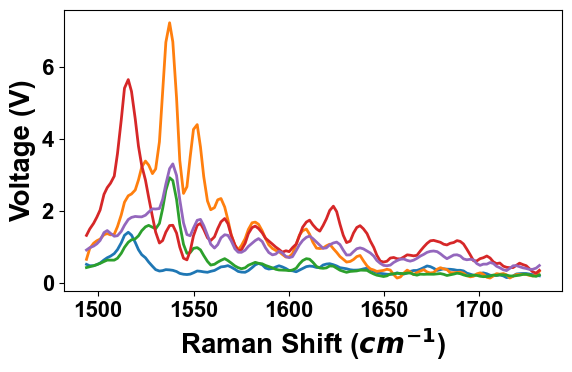

In [46]:

#N210
fig, ax = plot_pixel_spec(Vsrs_proc_hs, x=16, y=-9)
fig, ax = plot_pixel_spec(Vsrs_proc_hs, x=-60, y=21, ax=ax, fig=fig)
fig, ax = plot_pixel_spec(Vsrs_proc_hs, x=50, y=50, ax=ax, fig=fig)
fig, ax = plot_pixel_spec(Vsrs_proc_hs, x=38, y=35, ax=ax, fig=fig)
fig, ax = plot_pixel_spec(Vsrs_proc_hs, x=11, y=62, ax=ax, fig=fig)
plt.show()


# Calibrate Wavelength

In [49]:
Vsrs_hs['raman_shift']

<xarray.DataArray 'raman_shift' (raman_shift: 135)> Size: 1kB
array([1493.791641, 1495.497225, 1497.542944, 1499.246891, 1500.950095,
       1502.986367, 1504.68794 , 1506.388771, 1508.372136, 1510.071361,
       1512.052854, 1513.750476, 1515.7301  , 1517.42612 , 1519.403877,
       1521.098298, 1522.791982, 1524.767015, 1526.459103, 1528.432276,
       1530.12277 , 1532.094085, 1533.782989, 1535.471158, 1537.439763,
       1539.126345, 1541.093098, 1542.778094, 1544.742999, 1546.543358,
       1548.261037, 1549.977956, 1551.939218, 1553.654509, 1555.369041,
       1557.327578, 1559.040487, 1560.997169, 1562.708456, 1564.418986,
       1566.372953, 1568.081865, 1569.790022, 1571.741279, 1573.447822,
       1575.153611, 1577.102164, 1578.806342, 1580.753054, 1582.421908,
       1584.144576, 1586.081658, 1587.802693, 1589.522962, 1591.457347,
       1593.175987, 1594.893861, 1596.61097 , 1598.541804, 1600.257289,
       1601.97201 , 1603.90016 , 1605.613261, 1607.3256  , 1609.251071,
       1610.961793, 1612.671755, 1614.578811, 1616.314713, 1618.049833,
       1619.784169, 1621.517723, 1623.442977, 1625.174881, 1626.906005,
       1628.636348, 1630.365912, 1632.286735, 1634.014655, 1635.741797,
       1637.468161, 1639.193748, 1641.110157, 1642.834106, 1644.64875 ,
       1646.248107, 1648.024389, 1649.799846, 1651.574481, 1653.348293,
       1655.121284, 1656.893453, 1658.664801, 1660.435329, 1662.205037,
       1663.797074, 1665.565227, 1667.332562, 1669.099079, 1670.921978,
       1672.639331, 1674.355911, 1676.07172 , 1677.942632, 1679.656829,
       1681.370255, 1683.082912, 1684.794799, 1686.661436, 1688.371717,
       1690.08123 , 1691.789976, 1693.497956, 1695.360332, 1697.066711,
       1698.772324, 1700.477173, 1702.181258, 1704.039389, 1705.741879,
       1707.443605, 1709.144571, 1710.844774, 1712.698674, 1714.397288,
       1716.095141, 1717.839778, 1719.529389, 1721.218248, 1723.046997,
       1724.73429 , 1726.420833, 1728.106625, 1729.932054, 1731.616286])
Coordinates:
  * raman_shift  (raman_shift) float64 1kB 1.494e+03 1.495e+03 ... 1.732e+03
Attributes:
    units:    1/cm

## Using FFP peaks

In [11]:
# calib_dir = os.path.join(home_dir, "experiment_control","calibration_data","VCSEL_calibration")

fpath = os.path.join(calib_dir,'FFP-I_peaks')
FFP_cal_pks = load_hdf5(fpath=fpath)


loading file: FFP-I_peaks
importing peaks...


loading file: Spectra_wavmon_BOAfibBench_0.1nm_100us_5tlia_100reps_40dB_2025-12-07-17-04-16.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing Vsrs_θ...
importing Vsrs_θ_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
microvolt
importing attr sens_lia_units...
importing attr t_lia...
microsecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
loading file: FFP-I_peaks
importing peaks...


C:\Users\euyehara\AppData\Local\Temp\ipykernel_18004\595012904.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", num_reps)


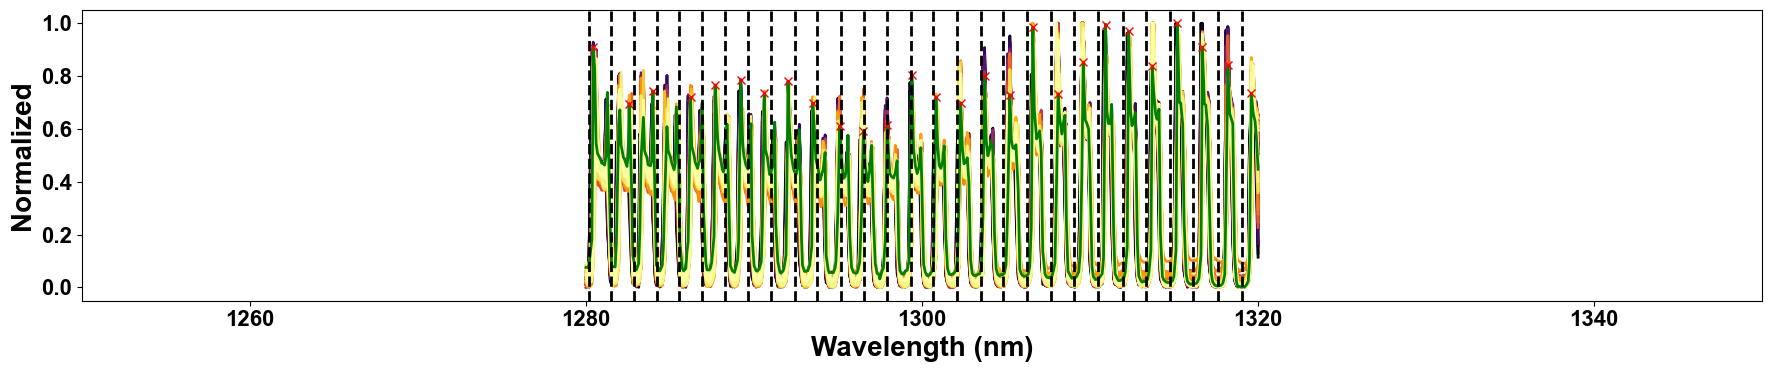

In [13]:
# Plot No Dichroic wavmon spectra

%matplotlib inline

dir_name = "Sample_test_PDFA_hole_2025-12-07-16-26-03"
# dir_name = "Sample_GSdev1b_Nikon20x_delayvolt16P2_2025-11-13-21-31-57"
fname = "Spectra_wavmon_BOAfibBench_0.1nm_100us_5tlia_100reps_40dB_2025-12-07-17-04-16.h5"
# fname ="Spectra_wavmon_microscopeOut_56VLP28mW_0.1nm_100us_5tlia_100reps_10dB_2025-12-08-18-53-06.h5"
# fname = "Spectra_test_FFP_GS_step0.1nm_300us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-51-30.h5"
# fname = "Spectra_test_FFP_GS_step0.1nm_100us_5tlia_noDichroic_30dB_100reps_2_2025-11-07-16-49-52.h5"

# fname = "Spectra_test_BOA700mA_PDFA_0.1nm_NoDichroic_100reps_10dB_100us_delayvolt16P2_2025-11-13-21-34-00.h5"
# fname = "HyperspecImg_Nikon20x_N150_CaroteneDiamond_1nm_300us_85min_6tlia_12dbdec_2025-11-02-22-00-59.h5"
fpath = os.path.join(data_dir, dir_name)
ds = load_data_from_file(fpath, fname)

# fig, ax = plot_daqsweep_wavmon(ds, id_sweep_dir=False, ds_type='sweep', colors=['b','g'], figsize=(12,4), num_reps=100)
fig, ax = plot_daqsweep_wavmon(ds, ds_type='sweep', figsize=(18,4), num_reps=None)
ax.set_xlim((1250, 1350))
plt.show()

# FFP peaks: 28


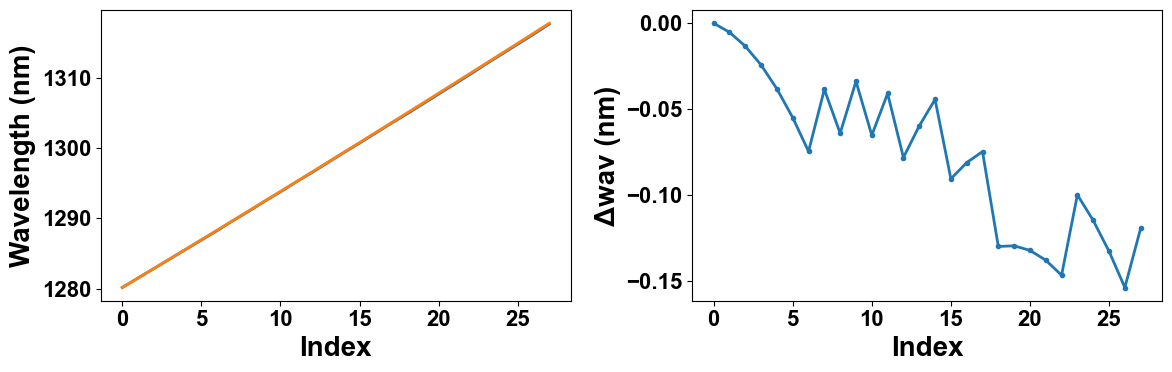

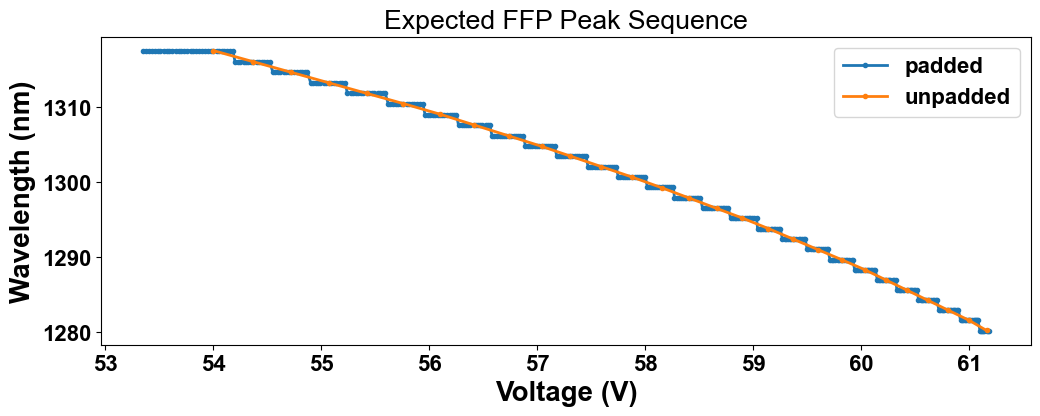

In [14]:
# Find FFP_pks in wav_set range
%matplotlib inline


#Remove repeated wavelengths from extra voltage padding
cal_pks = FFP_cal_pks["peaks"]
wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm


#restrict FFP_cal_pks to tuning range
FFP_osa = cal_pks[(cal_pks >= np.nanmin(ds['wavelength_set'])) & (cal_pks < np.nanmax(ds['wavelength_set'])-2*u.nm)] #manually remove 1343nm
FFP_osa = FFP_osa[~((FFP_osa > ds['wavelength_set'][0]) & (FFP_osa < ds['wavelength_set'][-1]))]


#calculate FFP_pk location given FSR
FSR = 247.35 * u.GHz
min_freq = (u.c /  np.min(FFP_osa)).to(u.GHz)
FFP_freq = np.arange(min_freq.m, (min_freq - (FFP_osa.shape[0]-1)*FSR).m, -FSR.m) * u.GHz
FFP_wav = (u.c / FFP_freq).to(u.nm)

#plot calculated values vs osa measured FFP values
fig, ax = plt.subplots(1, 2, figsize=(12,4), tight_layout=True)
ax[0].plot(range(FFP_osa.shape[0]), FFP_osa)
ax[0].plot(range(FFP_wav.shape[0]), FFP_wav)
ax[0].set_xlabel("Index")
ax[0].set_ylabel("Wavelength (nm)")

ax[1].plot(FFP_osa - FFP_wav, marker='.')
ax[1].set_xlabel("Index")
ax[1].set_ylabel("Δwav (nm)")

print(f"# FFP peaks: {FFP_wav.shape[0]}")

#Order by padded volt_set 
FFP_voltset = np.zeros(ds["wavelength_set"].shape)
for i,pk in enumerate(ds["wavelength_set"]):
    ind = np.argmin(np.abs(pk.m - FFP_osa.m))
    FFP_voltset[i] = FFP_osa[ind].m
   
FFP_voltset = FFP_voltset * u.nm

plt.figure(figsize=(12,4))
plt.plot(ds["HVA_Vset"], FFP_voltset, marker='.',label='padded')
plt.xlabel("Voltage (V)")
plt.ylabel("Wavelength (nm)")
plt.title("Expected FFP Peak Sequence")

#Order by unpadded volt_set
FFP_voltset = np.zeros(FFP_osa.shape)
volt_set = np.zeros(FFP_osa.shape)
for i,pk in enumerate(FFP_osa):
    ind = np.argmin(np.abs(pk.m - ds["wavelength_set"].m))
    FFP_voltset[i] = ds['wavelength_set'][ind].m
    volt_set[i] = ds["HVA_Vset"][ind].m
    
vs_i = np.argsort(volt_set)
FFP_voltset = FFP_voltset[vs_i] * u.nm
volt_set = volt_set[vs_i] * u.V

#interpolate volt_set and FFP_voltset
# voltset1_interp = np.linspace(volt_set[0], volt_set[np.argmin(FFP_voltset)], 2500) * u.V
# voltset2_interp = np.linspace(volt_set[np.argmax(FFP_voltset)], volt_set[-1], 2500) * u.V
# voltset_interp = np.concatenate((voltset1_interp.m, voltset2_interp.m)) * u.V

# FFPvoltset1_interp = np.interp(voltset1_interp.m, volt_set[:np.argmin(FFP_voltset)+1].m, FFP_voltset[:np.argmin(FFP_voltset)+1].m) * u.nm
# FFPvoltset2_interp = np.interp(voltset2_interp.m, volt_set[np.argmax(FFP_voltset):].m, FFP_voltset[np.argmax(FFP_voltset):].m) * u.nm
# FFPvoltset_interp = np.concatenate((FFPvoltset1_interp.m, FFPvoltset2_interp.m)) * u.nm

plt.plot(volt_set, FFP_voltset, marker='.', label='unpadded')
# plt.plot(voltset_interp, FFPvoltset_interp, marker='.')
plt.legend()

discontinuity low: 33.97 volt
discontinuity hi: 45.23 volt


C:\Users\euyehara\AppData\Local\Temp\ipykernel_18004\350427818.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", ds["num_sweep"])


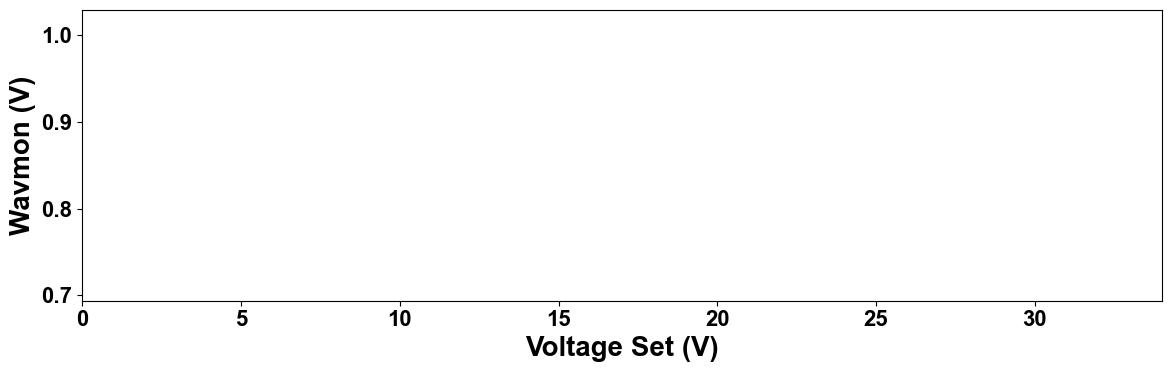

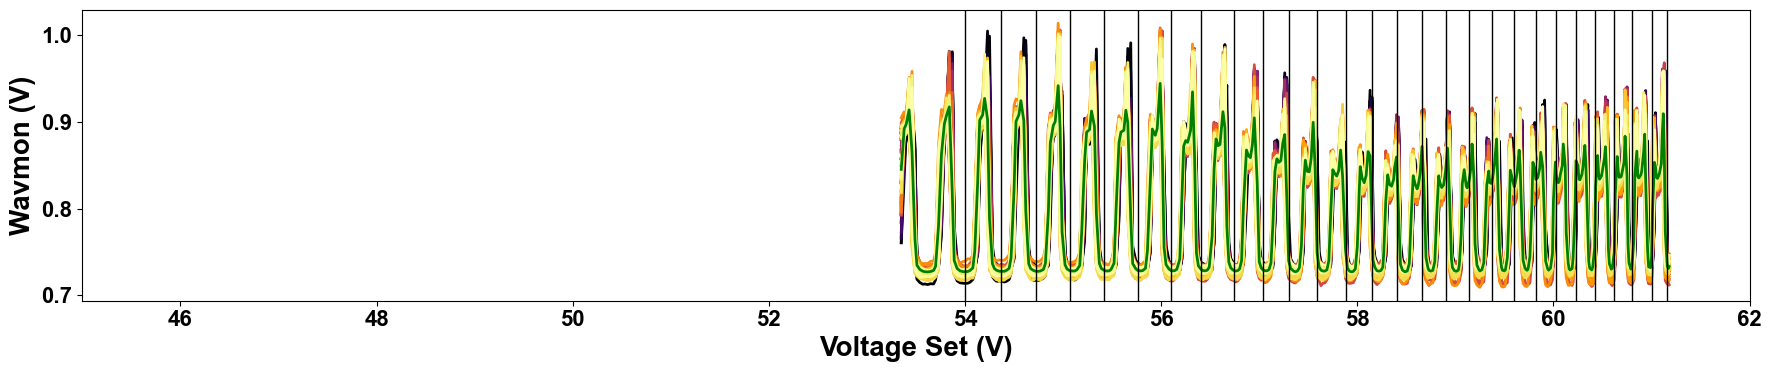

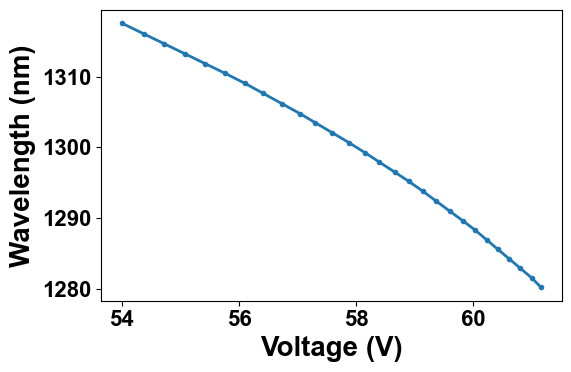

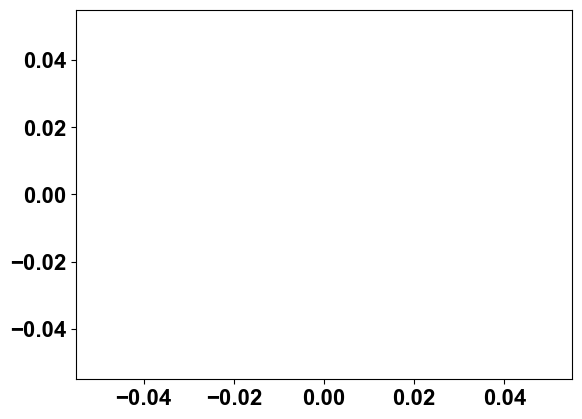

In [15]:
#Method 1) Assigning wavmon pulses by voltage proximity

# Plot voltage_sorted wavmon
wavmon_raw = np.reshape(ds["VCSEL_wavmon_raw"][1:].m, (ds["num_sweep"], ds["wavelength_set"].shape[0]))
wavmon_volt = deepcopy(wavmon_raw)

for row in range(wavmon_raw.shape[0]):
    if row % 2 != 0:
        wavmon_volt[row,:] = wavmon_raw[row,::-1]

# Before removing discontinuity
# fig, ax = plt.subplots(1,1, figsize=(12,4), tight_layout=True)
# ax.plot(ds["HVA_Vset"], wavmon_volt.T[:,:100])
# ax.set_xlabel("Voltage Set (V)")
# ax.set_ylabel("Wavmon (V)")
# ax.set_xlim(56,62)

# Identify wavvolt discontinuity and remove
a = io.loadmat(wavvolt_file) # Load wavvolt_file
wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
volt_calib = a['volt_interp'][0]*u.V
volt_disc_low = volt_calib[np.argmin(wav_calib)]
volt_disc_hi = volt_calib[np.argmax(wav_calib)]
print(f"discontinuity low: {volt_disc_low}")
print(f"discontinuity hi: {volt_disc_hi}")

disc_ind = np.where((ds["HVA_Vset"].m > volt_disc_low.m) & (ds["HVA_Vset"] < volt_disc_hi))
wavmon_volt[:,disc_ind] = np.nan

# Mean wavmon
wavmon_mean = np.mean(wavmon_volt, axis=0)
# Find peaks of mean wavmon
FFP_pks_ind, _ = find_peaks(wavmon_mean, prominence=0.1, height=6.5)
wavmon_pks = wavmon_mean[FFP_pks_ind]
# FFP_pks_ind, _ = find_peaks(wavmon_volt[0,:], prominence=0.1, height=6.5)
# wavmon_pks = wavmon_volt[0,FFP_pks_ind]

#filter out double peaks by proximity to expected location
wavmon_pks_filt = []#np.zeros(volt_set.shape)
# wavset_filt = np.zeros(volt_set.shape) 
FFP_filt = []
volt_filt = []# np.zeros(volt_set.shape)
colors = cm.get_cmap("inferno", ds["num_sweep"])
for i, volt in enumerate(volt_set):
    if volt < volt_disc_low: #Mode 1 has double peaks
       ind = np.argmin(np.abs(volt.m - ds["HVA_Vset"][FFP_pks_ind].m)) 
       volt_filt.append(ds["HVA_Vset"][FFP_pks_ind][ind].m)
       wavmon_pks_filt.append(wavmon_pks[ind])
volt_filt.extend(ds["HVA_Vset"][FFP_pks_ind][ds["HVA_Vset"][FFP_pks_ind] > volt_disc_hi].m)
wavmon_pks_filt.extend(wavmon_pks[ds["HVA_Vset"][FFP_pks_ind] > volt_disc_hi])
wavmon_pks_filt = wavmon_pks_filt*u.V
volt_filt = volt_filt*u.V

# Refind FFP_voltset (mapping of volt_filt (volt_set corresponding to wavmon peaks) to FFP peaks)
FFP_filt = np.zeros(volt_filt.shape)
for i,volt in enumerate(volt_filt):
    ind = np.argmin(np.abs(volt.m - volt_set.m))
    FFP_filt[i] = FFP_voltset[ind].m 
FFP_filt = FFP_filt * u.nm

fig, ax = plt.subplots(1,1, figsize=(12,4), tight_layout=True)
for sweep in range(ds["num_sweep"]):
    ax.plot(ds["HVA_Vset"], wavmon_volt[sweep,:], color=colors(sweep))
ax.plot(ds["HVA_Vset"], wavmon_mean, 'g')
# ax.plot(ds["HVA_Vset"], wavmon_volt[0,:], 'g')
ax.plot(ds["HVA_Vset"][FFP_pks_ind], wavmon_pks, 'x', color='r')
ax.plot(volt_filt, wavmon_pks_filt, 'x', color='b')
ax.set_xlabel("Voltage Set (V)")
ax.set_ylabel("Wavmon (V)")
for volt in volt_set.m:
    plt.axvline(volt, color='k', linestyle='-', linewidth=1)
ax.set_xlim((0,34))

fig, ax = plt.subplots(1,1, figsize=(18,4), tight_layout=True)
for sweep in range(ds["num_sweep"]):
    ax.plot(ds["HVA_Vset"], wavmon_volt[sweep,:], color=colors(sweep))
ax.plot(ds["HVA_Vset"], wavmon_mean, 'g')
# ax.plot(ds["HVA_Vset"], wavmon_volt[0,:], 'g')
ax.plot(ds["HVA_Vset"][FFP_pks_ind], wavmon_pks, 'x', color='r')
ax.plot(volt_filt, wavmon_pks_filt, 'x', color='b')
ax.set_xlabel("Voltage Set (V)")
ax.set_ylabel("Wavmon (V)")
for volt in volt_set.m:
    plt.axvline(volt, color='k', linestyle='-', linewidth=1)
ax.set_xlim((45,62))


#Plot new wavvolt
fig, ax = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax.plot(volt_set, FFP_voltset, marker='.', label='expected')
ax.plot(volt_filt, FFP_filt, marker='.', label='measured')
plt.xlabel("Voltage (V)")
plt.ylabel("Wavelength (nm)")
# ax.set_xlim(50,60)

# #Interpolate volt_filt
# voltfilt1_interp = np.linspace(volt_filt[0], volt_filt[np.argmin(FFP_filt)], 2500) * u.V
# voltfilt2_interp = np.linspace(volt_filt[np.argmax(FFP_filt)], volt_filt[-1], 2500) * u.V
# voltfilt_interp = np.concatenate((voltfilt1_interp.m, voltfilt2_interp.m)) * u.V

# FFPvoltfilt1_interp = np.interp(voltfilt1_interp.m, volt_filt[:np.argmin(FFP_filt)+1].m, FFP_filt[:np.argmin(FFP_filt)+1].m) * u.nm
# FFPvoltfilt2_interp = np.interp(voltfilt2_interp.m, volt_filt[np.argmax(FFP_filt):].m, FFP_filt[np.argmax(FFP_filt):].m) * u.nm
# FFPvoltfilt_interp = np.concatenate((FFPvoltfilt1_interp.m, FFPvoltfilt2_interp.m))

# ax.plot(voltfilt_interp, FFPvoltfilt_interp, marker='.')

# Check that volt_filt is monotonic
plt.figure()
plt.plot(volt_filt, marker='.')
plt.plot(ds["HVA_Vset"][FFP_pks_ind], marker='.')






loading file: Spectra_diamond_FFP_GS_step0.1nm_300us300uV_5tlia_60dB_10reps_2025-11-07-17-24-20.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
(931, 10)
raman peaks: [29.77 61.04] volt


C:\Users\euyehara\AppData\Local\Temp\ipykernel_26552\4038905829.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("inferno", ds["num_sweep"])


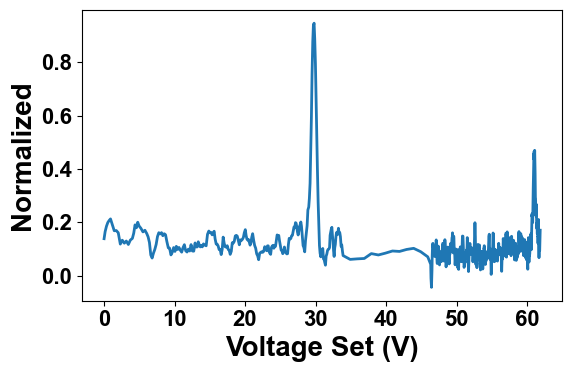

(45.0, 62.0)

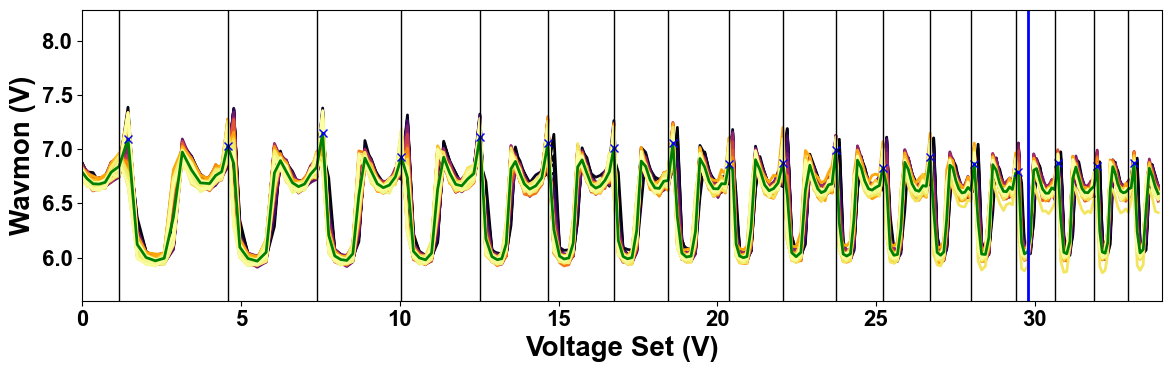

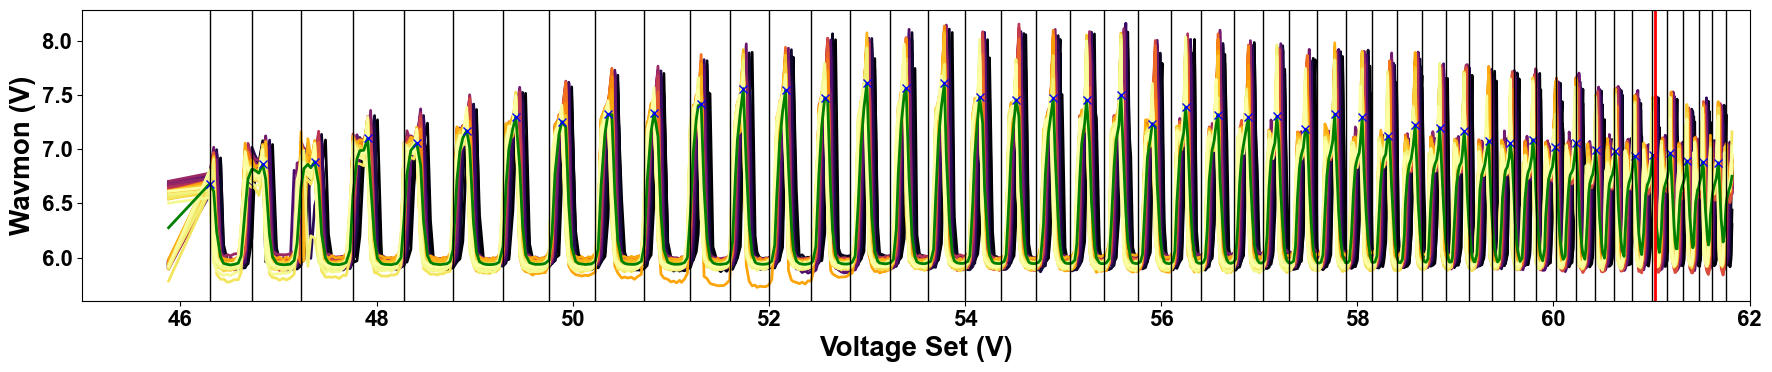

In [88]:
#Identifying wavmon peak by diamond and B-carotene Raman reference
colors = cm.get_cmap("inferno", ds["num_sweep"])

dir_name = "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"
fname2 = "Spectra_diamond_FFP_GS_step0.1nm_300us300uV_5tlia_60dB_10reps_2025-11-07-17-24-20.h5"
fpath2 = os.path.join(data_dir, dir_name)
ds2 = load_data_from_file(fpath2, fname2)

#Smooth
Vsrs_smooth = np.zeros(ds2['Vsrs_arr'].shape)
for row in range(ds2['Vsrs_arr'].shape[0]):
    Vsrs_smooth[row] = savgol_filter(ds2['Vsrs_arr'][row,:], 10, 2)
    
# normalize data to max peak
Vsrs_norm = Vsrs_smooth.T / np.max(Vsrs_smooth, axis=1)
Vsrs_mean = np.mean(Vsrs_norm, axis=1)
print(Vsrs_norm.shape)

raman_pk_i, _ = find_peaks(Vsrs_mean, prominence=0.2, height=0.3)
print(f"raman peaks: {ds2['HVA_Vset'][raman_pk_i]}")

fig, ax = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax.plot(ds2['HVA_Vset'], Vsrs_mean)
ax.set_xlabel("Voltage Set (V)")
ax.set_ylabel("Normalized")
# plot_daqsweep_wavmon(ds, id_sweep_dir=False, colors=['r','k'], figsize=(18,4), normalize=True, num_reps=10, ax=ax, fig=fig)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
# fig, ax = plot_daq_sweepSpectra(ds2, fig=fig, ax=ax, verbose=False)
plt.show()

# Plot raman peaks on no dichoic wavmon
diamond_volt = ds2['HVA_Vset'][raman_pk_i[0]]
Bcarotene_volt = ds2['HVA_Vset'][raman_pk_i[1]]

fig, ax = plt.subplots(1,1, figsize=(12,4), tight_layout=True)
for sweep in range(ds["num_sweep"]):
    ax.plot(ds["HVA_Vset"], wavmon_volt[sweep,:], color=colors(sweep))
# ax.plot(ds["HVA_Vset"], wavmon_volt.T[:,:100])
ax.plot(ds["HVA_Vset"], wavmon_mean, 'g')
# ax.plot(ds["HVA_Vset"][FFP_pks_ind], wavmon_pks, 'x', color='r')
ax.plot(volt_filt, wavmon_pks_filt, 'x', color='b')
ax.set_xlabel("Voltage Set (V)")
ax.set_ylabel("Wavmon (V)")
for volt in volt_set.m:
    plt.axvline(volt, color='k', linestyle='-', linewidth=1)
plt.axvline(diamond_volt.m, color='b')
plt.axvline(Bcarotene_volt.m, color='r')
ax.set_xlim((0,34))

fig, ax = plt.subplots(1,1, figsize=(18,4), tight_layout=True)
for sweep in range(ds["num_sweep"]):
    ax.plot(ds["HVA_Vset"], wavmon_volt[sweep,:], color=colors(sweep))
# ax.plot(ds["HVA_Vset"], wavmon_volt.T[:,:100])
ax.plot(ds["HVA_Vset"], wavmon_mean, 'g')
# ax.plot(ds["HVA_Vset"][FFP_pks_ind], wavmon_pks, 'x', color='r')
ax.plot(volt_filt, wavmon_pks_filt, 'x', color='b')
ax.set_xlabel("Voltage Set (V)")
ax.set_ylabel("Wavmon (V)")
for volt in volt_set.m:
    plt.axvline(volt, color='k', linestyle='-', linewidth=1)
plt.axvline(diamond_volt.m, color='b')
plt.axvline(Bcarotene_volt.m, color='r')
ax.set_xlim((45,62))

29.48 volt
1253.7036295369212 nanometer
61.01 volt
1282.9161451814766 nanometer


c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\numpy\ma\core.py:2820: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  _data = np.array(data, dtype=dtype, copy=copy,


Text(0, 0.5, 'Wavelength (nm)')

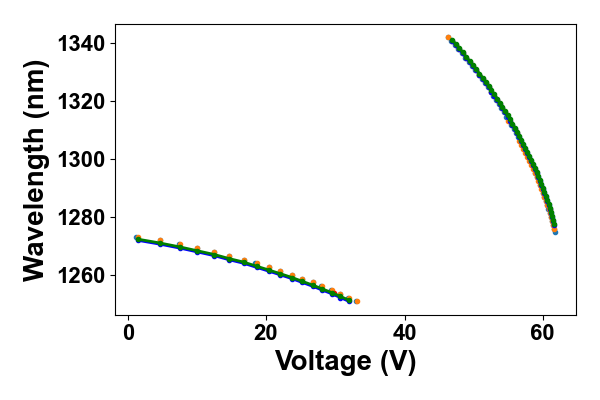

In [89]:
#Use diamond and B-carotene stokes wavelengths and set voltages as ground truth references
#Assign remaining wavmon peaks by order of occurence around reference points
%matplotlib widget

# Find diamond and B-carotene peaks
diamond_stokes = (1/(1/ds2["pump_wav"] - 1333/u.cm)).to(u.nm)
Bcarotene_stokes = (1/(1/ds2["pump_wav"] - 1513/u.cm)).to(u.nm)

# Innitialize new wavvolt mapping volt_filt of wavmon peaks to FFP wavelengths
FFP_assign = np.full(volt_filt.shape, np.nan)

#Find wavmon voltage set closest to diamond and B-carotene peak set voltage
wavmon_dia_i = np.argmin(np.abs(diamond_volt - volt_filt))
wavmon_Bcarot_i = np.argmin(np.abs(Bcarotene_volt - volt_filt))
#Find FFP wavelength closest to diamond stokes wavelength
FFP_dia_i = np.argmin(np.abs(diamond_stokes - FFP_voltset))
FFP_Bcarot_i = np.argmin(np.abs(Bcarotene_stokes - FFP_voltset))

print(volt_filt[wavmon_dia_i])
print(FFP_voltset[FFP_dia_i])
print(volt_filt[wavmon_Bcarot_i])
print(FFP_voltset[FFP_Bcarot_i])

#Assign reference points
FFP_assign[wavmon_dia_i] = FFP_voltset[FFP_dia_i].m
FFP_assign[wavmon_Bcarot_i] = FFP_voltset[FFP_Bcarot_i].m

#Assign remaining points by order of occurance
mode1_end = np.argmin(np.abs(volt_filt - volt_disc_low))
mode2_start = np.argmin(np.abs(volt_filt - volt_disc_hi))

mode2_end = FFP_assign.shape[0] - wavmon_Bcarot_i
FFP_assign[0:wavmon_dia_i] = FFP_voltset[FFP_dia_i-wavmon_dia_i:FFP_dia_i].m
FFP_assign[wavmon_dia_i:mode1_end] = FFP_voltset[FFP_dia_i:FFP_dia_i+(mode1_end-wavmon_dia_i)].m
FFP_assign[mode2_start+1:wavmon_Bcarot_i] = FFP_voltset[FFP_Bcarot_i-(wavmon_Bcarot_i-mode2_start)+1:FFP_Bcarot_i].m
FFP_assign[wavmon_Bcarot_i:] = FFP_voltset[FFP_Bcarot_i:FFP_Bcarot_i+mode2_end].m

#Append ground truth values
# volt_final = np.concatenate((volt_filt.m, [diamond_volt.m, Bcarotene_volt.m])) * u.V
# FFP_final = np.concatenate((FFP_assign, [diamond_stokes.m, Bcarotene_stokes.m])) * u.V
# s_ind = np.argsort(volt_final)
# FFP_final = FFP_final[s_ind]
FFP_shift = FFP_assign + 0.4
# Plot new wavvolt
fig, ax = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax.scatter(volt_set, FFP_voltset, marker='.', label='expected')
ax.scatter(volt_filt, FFP_filt, marker='.', label='measured')
ax.plot(volt_filt, FFP_assign, marker='.', label='calibrated', color='b')
ax.plot(volt_filt, FFP_shift, marker='.', label='shift', color='g')
ax.scatter([diamond_volt.m, Bcarotene_volt.m], [diamond_stokes.m, Bcarotene_stokes.m], marker='.', color='r')
# ax.plot(volt_filt[:mode1_end], FFP_assign[:mode1_end], marker='.', label='calibrated', color='r')
# ax.plot(volt_filt[mode2_start+1:], FFP_assign[mode2_start+1:], marker='.', label='calibrated', color='r')

plt.xlabel("Voltage (V)")
plt.ylabel("Wavelength (nm)")
# ax.set_xlim(50,60)

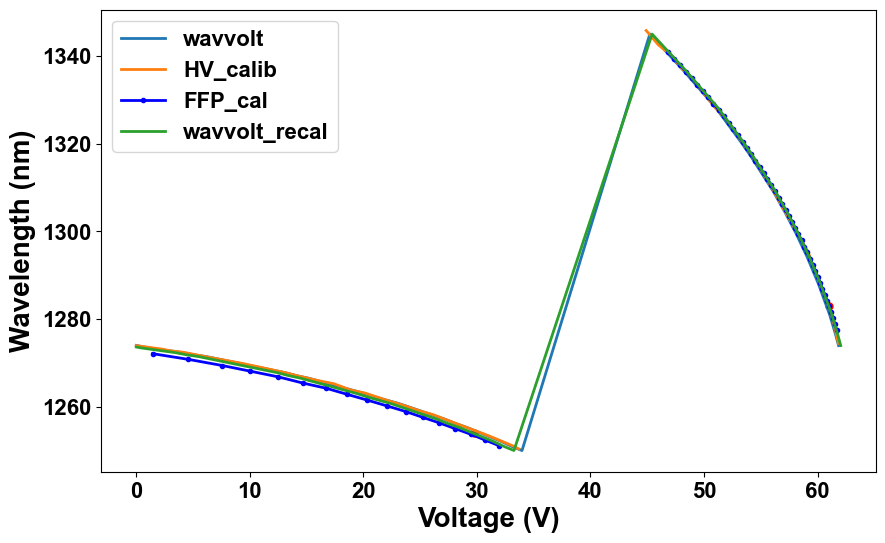

In [ ]:
# Save recalibrated wavvolt

%matplotlib inline 

# Load wavvolt_file
a = io.loadmat(wavvolt_file)
wav_calib = (a['peak_interp'][0] * u.m).to(u.nm)
volt_calib = a['volt_interp'][0]*u.V

volt1_interp = np.linspace(volt_calib[0], volt_calib[np.argmin(wav_calib)-1], 2500) 
volt2_interp = np.linspace(volt_calib[np.argmax(wav_calib)+1], volt_calib[-1], 2500) 

mode1_interp = np.interp(volt1_interp, volt_calib[:np.argmin(wav_calib)], wav_calib[:np.argmin(wav_calib)]*1e-9)
mode2_interp = np.interp(volt2_interp, volt_calib[np.argmax(wav_calib)+1:], wav_calib[np.argmax(wav_calib)+1:]*1e-9)


volt1_shift = volt1_interp - 0.7*u.V
mode1_shift = mode1_interp[volt1_shift >= 0*u.V]
volt1_shift = volt1_shift[volt1_shift >= 0*u.V]


volt2_shift = volt2_interp + 0.19*u.V
mode2_shift = mode2_interp[volt2_shift >= 0*u.V]
volt2_shift = volt2_shift[volt2_shift >= 0*u.V]


plt.figure(figsize=(10,6))
plt.plot(volt_calib, wav_calib, label="wavvolt")

b = io.loadmat(wavvolt_HVCALIB)
wav_calib = (b['peak_interp'][0] * u.m).to(u.nm)
volt_calib = b['volt_interp'][0]*u.V
plt.plot(volt_calib, wav_calib, label="HV_calib")
plt.plot(volt_filt, FFP_assign, marker='.', label='FFP_cal', color='b')

plt.xlabel("Voltage (V)")
plt.ylabel("Wavelength (nm)")

data = {
    'peak_interp': np.concatenate((mode1_shift, mode2_shift)),
    'volt_interp': np.concatenate((volt1_shift, volt2_shift))
}

#Saving calibration file
mat_fname = 'wavvolt16_sweepcal.mat'
file_dir = os.path.join(calib_dir, mat_fname)
plt.plot(data['volt_interp'], data['peak_interp']*1e9, label='wavvolt_recal')
plt.scatter([diamond_volt.m, Bcarotene_volt.m], [diamond_stokes.m, Bcarotene_stokes.m], marker='.', color='r', s=100)
# plt.xlim(45,63)
# plt.ylim(1270,1350)
plt.legend()

io.savemat(file_dir, data)

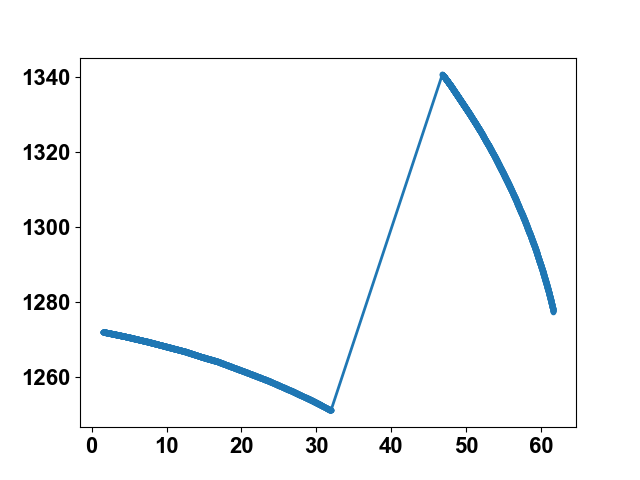

In [463]:
a = io.loadmat(wavvolt_sweepcal)
wav_calib = (a['peak_interp'][0] * u.m).to(u.nm)
volt_calib = a['volt_interp'][0]*u.V

plt.figure()
plt.plot(volt_calib, wav_calib, marker='.', label="wavvolt")


c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\scipy-1.14.1-py3.12-win-amd64.egg\scipy\signal\_peak_finding.py:266: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  value = np.asarray(value, order='C', dtype=np.float64)


[1250.3008760951188, 1250.7949937421777, 1251.6027534418022, 1252.2037546933666, 1252.9992490613265, 1253.5038798498122, 1254.3028785982478, 1254.9021276595745, 1255.5994993742177, 1256.0988735919898, 1256.903128911139, 1257.5006257822279, 1258.2015018773466, 1258.7972465581977, 1259.4981226533166, 1260.1026282853566, 1260.9016270337922, 1261.3992490613266, 1262.0020025031288, 1262.6958698372964, 1263.3967459324153, 1264.0976220275343, 1264.7003754693367, 1265.4012515644556, 1266.1021276595745, 1266.7994993742177, 1267.3987484355441, 1268.099624530663, 1268.6988735919897, 1269.2981226533166, 1270.002503128911, 1270.7016270337922, 1271.4007509386734, 1271.9982478097622, 1272.7008760951187, 1273.3001251564456, 1273.9799749687108, 1274.8998748435545, 1275.670838548185, 1276.3454317897372, 1277.116395494368, 1277.8978723404255, 1278.5707133917394, 1279.327659574468, 1280.000500625782, 1280.8415519399248, 1281.4302878598246, 1282.215269086358, 1282.7759699624528, 1283.6170212765956, 1284.17

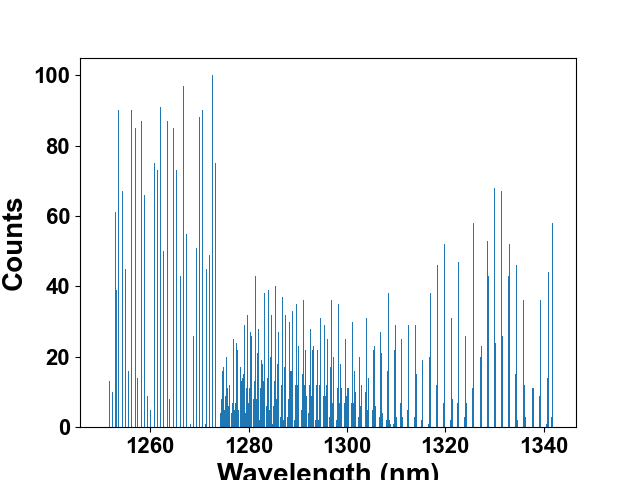

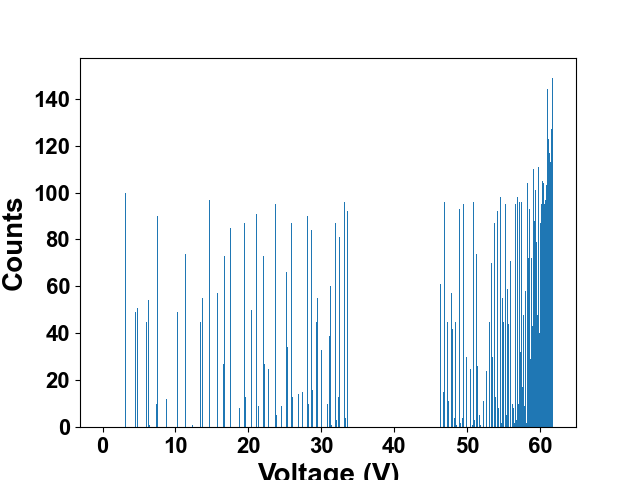

In [83]:
#id peaks on 0.1nm sweep
%matplotlib widget

from scipy.signal import find_peaks

peak_wls = []
volts = []
wl_res = 0.1 * u.nm
volt_res = 0.1 * u.V
thresh = 30

wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm
wavmon_arr = ds["VCSEL_wavmon_arr"][:, s_ind]
volt_set = ds["HVA_Vset"][s_ind]

# Find peaks in sweep unwrapped spectra, append wavelength of peaks to vector
for row in range(wavmon_arr.shape[0]):
    FFP_pks_ind, _ = find_peaks(wavmon_arr[row], prominence=0.1, height=6.5)
    FFP_pks = wavset_sort[FFP_pks_ind]
    volt_pks = volt_set[FFP_pks_ind]
    peak_wls.extend(FFP_pks.m)
    volts.extend(volt_pks.m)

print(peak_wls)
wl_bins = int((np.max(peak_wls)-np.min(peak_wls)) / wl_res.m)
volt_bins = int((np.max(volts)-np.min(volts)) / volt_res.m)
print(f'wl_bins: {wl_bins}')

# Plot histogram of id'd peaks
plt.figure()
# for wl in FFP_cal_pks['peaks'].m:
#     plt.axvline(wl, color='k', linestyle='-', linewidth=1)
plt.hist(peak_wls, bins=wl_bins)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Counts")

plt.figure()
plt.hist(volts, bins=volt_bins )
plt.xlabel("Voltage (V)")
plt.ylabel("Counts")
# reject peaks with few counts / xx std from peak norm
hist, bin_edges = np.histogram(peak_wls, bins=wl_bins)
print(len(hist))
sel = np.where(hist > thresh)
# print(len(hist[sel]))
bin_cent = np.diff(bin_edges) / 2 + bin_edges[:-1]

print(bin_cent)

# print(bin_cent[sel])
# hist_less = hist[sel]

# plt.figure()
# plt.bar(bin_cent, hist)
# plt.figure()
# plt.bar(bin_cent[sel], hist[sel])
# for wl in FFP_cal_pks['peaks'].m:
#     plt.axvline(wl, color='k', linestyle='-', linewidth=1)



# for row in range(4):
#     if row %2 != 0:
#         ax.plot(wavset_sort, wavmon_arr[row], '.-', color=odd_color)
#     else:
#         ax.plot(wavset_sort, wavmon_arr[row], '.-', color=even_color)


In [70]:
volts

[33.69,
 33.22,
 32.53,
 32.04,
 31.29,
 30.810000000000002,
 30.049999999999997,
 29.48,
 28.78,
 28.21,
 27.41,
 26.810000000000002,
 26.009999999999998,
 25.33,
 24.53,
 23.84,
 22.91,
 22.2,
 21.34,
 20.48,
 19.6,
 18.6,
 17.740000000000002,
 16.740000000000002,
 15.74,
 14.66,
 13.64,
 12.52,
 11.38,
 10.24,
 8.9,
 7.57,
 6.24,
 4.7700000000000005,
 3.15,
 1.44,
 0.0,
 61.75,
 61.67,
 61.6,
 61.519999999999996,
 61.43,
 61.35,
 61.26,
 61.18,
 61.08,
 61.01,
 60.9,
 60.82,
 60.699999999999996,
 60.62,
 60.5,
 60.42,
 60.3,
 60.22,
 60.089999999999996,
 60.0,
 59.87,
 59.78,
 59.65,
 59.55,
 59.42,
 59.32,
 59.17,
 59.089999999999996,
 58.92,
 58.83,
 58.66,
 58.57,
 58.4,
 58.129999999999995,
 58.05,
 57.85,
 57.57,
 57.489999999999995,
 57.26,
 56.949999999999996,
 56.65,
 56.339999999999996,
 56.269999999999996,
 56.01,
 55.66,
 55.32,
 54.989999999999995,
 54.62,
 54.25,
 53.87,
 53.489999999999995,
 53.08,
 52.68,
 52.25,
 51.83,
 51.370000000000005,
 50.93,
 50.46,
 49.99,
 4

(0.0, 2.0)

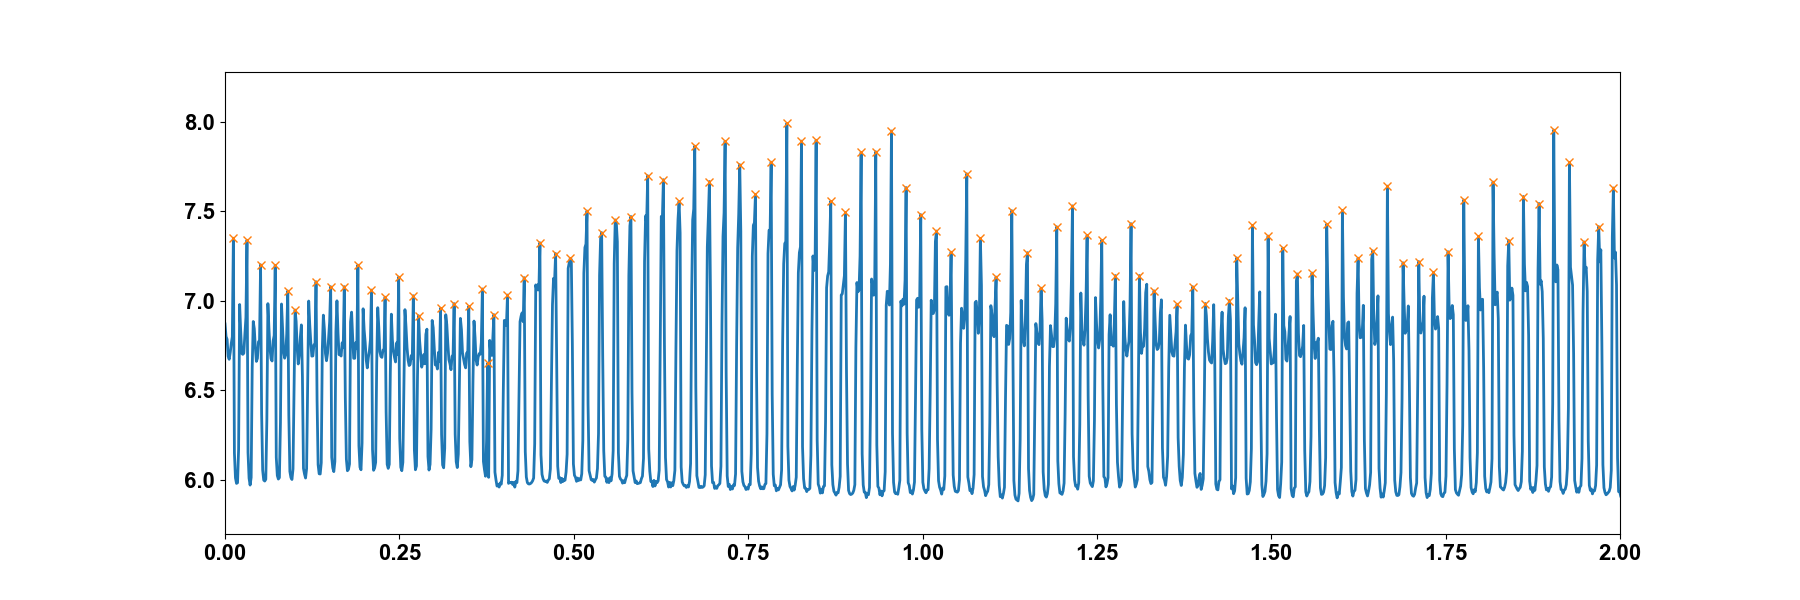

In [44]:
wavmon_pksind_raw, _ = find_peaks(ds['VCSEL_wavmon_raw'], prominence=0.5, height=6.5)
wavmon_pks_raw = ds['t'][wavmon_pksind_raw]
plt.figure(figsize=(18,6))
plt.plot(ds['t'], ds['VCSEL_wavmon_raw'])
plt.plot(ds['t'][wavmon_pksind_raw], ds['VCSEL_wavmon_raw'][wavmon_pksind_raw], 'x')
plt.xlim((0,2))
# plt.xlabel("Time (s)")
# plt.ylabel("wavmon")


<>:98: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:98: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:103: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
C:\Users\euyehara\AppData\Local\Temp\ipykernel_30508\8617497.py:98: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\AppData\Local\Temp\ipykernel_30508\8617497.py:100: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\AppData\Local\Temp\ipykernel_30508\8617497.py:103: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_ylabel("Voltage $(\mu V)$")
C:\Users\euyehara\AppData\Local\Temp\ipykernel_30508\8617497.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel

loading file: Spectra_test_FFP_GS_step0.1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-47-40.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
loading file: Spectra_diamond_FFP_GS_step0.1nm_300us300uV_5tlia_60dB_10reps_2025-11-07-17-24-20.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
i

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


loading file: FFP-I_peaks
importing peaks...


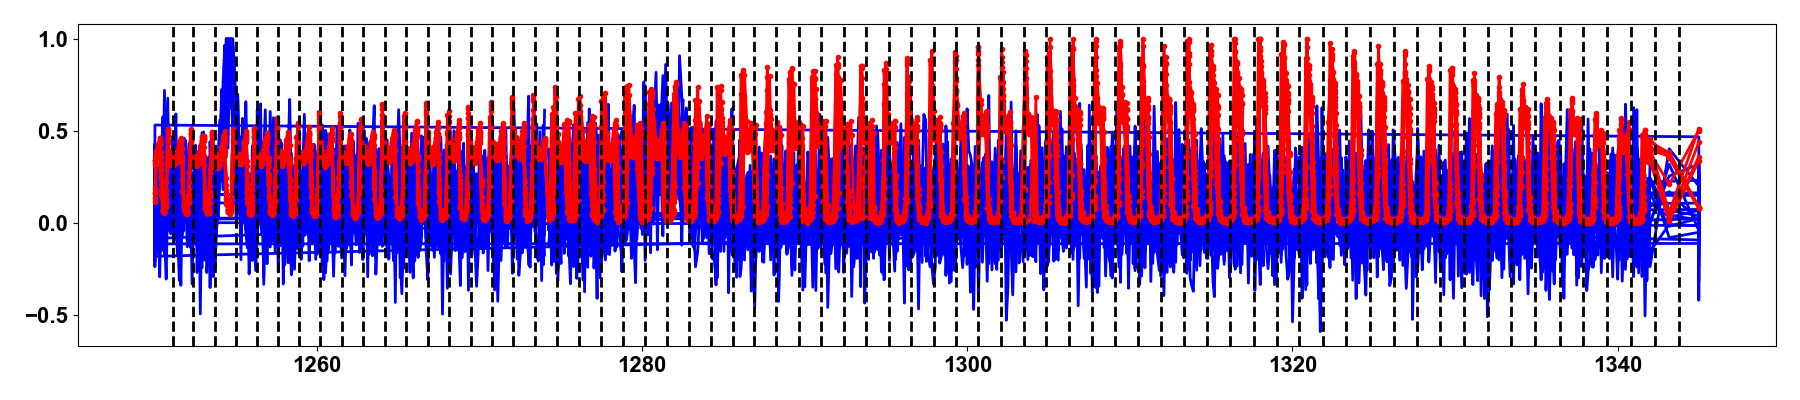

In [29]:
# For DAQ sweep

dir_name = "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"
fname ="Spectra_test_FFP_GS_step0.1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-47-40.h5"
fpath = os.path.join(data_dir, dir_name)
ds = load_data_from_file(fpath, fname)


dir_name = "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"
# fname2 ="Spectra_test_FFP_GS_step0.1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-47-40.h5"  #Repeat 100us
# fname2 ="Spectra_test_FFP_GS_step0.1nm_300us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-51-30.h5"  #Compare to 300us
# fname2 = "Spectra_test_FFP_GS_step0.1nm_100us_Dichroic_60dB_2025-11-06-21-00-01.h5" #Compare to dichroic, 100us
# fname2 = "Spectra_test_FFP_GS_step1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-17-01-05.h5"  #Compare to 1nm step
fname2 = "Spectra_diamond_FFP_GS_step0.1nm_300us300uV_5tlia_60dB_10reps_2025-11-07-17-24-20.h5"

fpath2 = os.path.join(data_dir, dir_name)
ds2 = load_data_from_file(fpath2, fname2)
# normalize data to max peak
Vsrs_norm = ds2['Vsrs_arr'].T / np.max(ds2['Vsrs_arr'], axis=1)
print(Vsrs_norm.shape)
# for rep in ds2['Vsrs_arr'].shape[0]:
    

cal_pks = FFP_cal_pks["peaks"]
wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm

#restrict FFP_cal_pks to tuning range
FFP_cal = cal_pks[(cal_pks >= np.nanmin(ds['wavelength_set'])) & (cal_pks <= np.nanmax(ds['wavelength_set']))] 
FFP_cal = FFP_cal[~((FFP_cal > ds['wavelength_set'][0]) & (FFP_cal < ds['wavelength_set'][-1]))]



%matplotlib widget
fig, ax = plt.subplots(1,1, figsize=(18,4), tight_layout=True)
ax.plot(ds2['wavelength_set'], Vsrs_norm, color='b')
plot_daqsweep_wavmon(ds, id_sweep_dir=False, colors=['r','k'], figsize=(18,4), normalize=True, num_reps=10, ax=ax, fig=fig)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
# fig, ax = plot_daq_sweepSpectra(ds2, fig=fig, ax=ax, verbose=False)
plt.show()



# Create wavamp_file 

In [189]:
#DELETE LATER! ALREADY MOVED TO PLOT_SRS.PY

def find_peak_delay(ds0, sgolay_winlen, sgolay_polyord):
    smoothed = np.zeros(ds0['trace_aray'].shape)
    pks_val = []
    pks_loc = []

    #shift to center at first peak
    pk0_i = np.argmax(ds0['trace_aray'][0,:])
    time = ds0['x_axis'] - ds0['x_axis'][pk0_i]
    for ind in range(ds0['trace_aray'].shape[0]):
        smoothed[ind, :] = savgol_filter(ds0['trace_aray'][ind,:], window_length=sgolay_winlen, polyorder=sgolay_polyord)
        Mind = np.argmax(smoothed[ind,:])
        pks_val.append(smoothed[ind, Mind])
        pks_loc.append(time[Mind].m) 
    pks_loc = np.array(pks_loc)*u.s
    pks_norm = pks_val/ np.max(pks_val)
    fig,ax0 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
    ax0.plot(time.to(u.ps), smoothed.T)
    ax0.scatter(pks_loc.to(u.ps), pks_val, marker='x', color='r')
    ax0.set_xlabel("Time [ps]")
    ax0.set_ylabel("Voltage [V]")
    
    return pks_val, pks_loc, pks_norm

In [ ]:
fpath = os.path.join(data_dir,"Sample_Test_VCSEL_sweep_CW_2025-03-21-16-46-04")
# fname0 = "testSweep_osc_dev1b_delayvolt16P2_OE1076CW159mA_RBW0.10nm_2025-12-09-15-12-01.h5"
fname0 = "testSweep_osc_dev1b_ampBOAonly_1nm_delayvolt17D_OE1076CW159mA_RBW0.10nm_2025-12-13-19-15-40.h5"
fname1 = "testSweep_osc_dev1b_ampBOAonly_1_delayvolt16_OE1076CW159mA_RBW0.10nm_2025-12-11-22-39-01.h5"
fname2 = "testSweep_osc_dev1b_ampBOAonly_1nm_delayvolt16D_OE1076CW159mA_RBW0.10nm_2025-12-12-15-41-57.h5"
fname3 = "testSweep_osc_dev1b_ampCAL_1310_4_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-16-38-53.h5"
fname4 = "testSweep_osc_dev1b_ampCAL_1310_5_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-17-04-46.h5"
fname5 = "testSweep_osc_dev1b_ampCAL_1310_6_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-17-42-39.h5"
fname6 = "testSweep_osc_dev1b_ampCAL_1310_7_delayvolt16P3_OE1076CW159mA_RBW0.10nm_2025-12-10-18-18-29.h5"

ds0=load_data_from_file(fpath, fname0)
ds1=load_data_from_file(fpath, fname1)
ds2=load_data_from_file(fpath, fname2)
ds3=load_data_from_file(fpath, fname3)
ds4=load_data_from_file(fpath, fname4)
ds5=load_data_from_file(fpath, fname5)
ds6=load_data_from_file(fpath, fname6)

In [ ]:
win_len = 100
polyorder = 3

pks_val0, pks_loc0, pks_norm0 = find_peak_delay(ds0, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val1, pks_loc1, pks_norm1 = find_peak_delay(ds1, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val2, pks_loc2, pks_norm2 = find_peak_delay(ds2, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val3, pks_loc3, pks_norm3 = find_peak_delay(ds3, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val4, pks_loc4, pks_norm4 = find_peak_delay(ds4, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val5, pks_loc5, pks_norm5 = find_peak_delay(ds5, sgolay_winlen=win_len, sgolay_polyord=polyorder)
# pks_val6, pks_loc6, pks_norm6 = find_peak_delay(ds6, sgolay_winlen=win_len, sgolay_polyord=polyorder)


In [ ]:
#Plot time delay of peaks vs wavelength
fig,ax1 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax1.plot(ds0["wavelength_set"].to(u.nm), pks_loc0.to(u.ps), marker='.')
# ax1.plot(ds1["wavelength_set"].to(u.nm), pks_loc1.to(u.ps), marker='.')
# ax1.plot(ds2["wavelength_set"].to(u.nm), pks_loc2.to(u.ps), marker='.')
# ax1.plot(ds3["wavelength_set"].to(u.nm), pks_loc3.to(u.ps), marker='.')
# ax1.plot(ds4["wavelength_set"].to(u.nm), pks_loc4.to(u.ps), marker='.')
# ax1.plot(ds5["wavelength_set"].to(u.nm), pks_loc5.to(u.ps), marker='.')
# ax1.plot(ds6["wavelength_set"].to(u.nm), pks_loc6.to(u.ps), marker='.')
ax1.set_xlabel("Wavelength [nm]")
ax1.set_ylabel("Time [ps]")
plt.show()

In [ ]:
#Plot unnormalized pulse amplitude vs wavelength
fig,ax2 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax2.plot(ds0["wavelength_set"].to(u.nm), pks_val0, marker='.', label='0')
# ax2.plot(ds1["wavelength_set"].to(u.nm), pks_val1, marker='.', label='1')
# ax2.plot(ds2["wavelength_set"].to(u.nm), pks_val2, marker='.', label='2')
# ax2.plot(ds3["wavelength_set"].to(u.nm), pks_val3, marker='.', label='3')
# ax2.plot(ds4["wavelength_set"].to(u.nm), pks_val4, marker='.', label='4')
# ax2.plot(ds5["wavelength_set"].to(u.nm), pks_val5, marker='.', label='5')
# ax2.plot(ds6["wavelength_set"].to(u.nm), pks_val6, marker='.', label='6')
ax2.set_xlabel("Wavelength [nm]")
ax2.set_ylabel("Amplitude")
plt.legend()
wavelength_set=ds0["wavelength_set"].to(u.nm)
# pks_arr = np.stack((pks_norm0, pks_norm1, pks_norm2, pks_norm3, pks_norm4, pks_norm5, pks_norm6))
pks_arr = np.stack((pks_norm0, pks_norm1, pks_norm2))
pks_av = np.mean(pks_arr, axis=0)
print(pks_av.shape)

fig,ax3 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax3.plot(ds0["wavelength_set"].to(u.nm), pks_arr.T, marker='.')
ax3.plot(ds0["wavelength_set"].to(u.nm), pks_av, marker='.', color='k')

In [ ]:


# Interpolate pks_av and create amplitude_scale
wavelength_interp = np.linspace(1280, 1320, 5000)
#reorder by increasing voltage

#load wavvolt_file
a = io.loadmat(wavvolt_file) # Load wavvolt_file
wav_calib =  (a['peak_interp'][0] * u.m).to(u.nm)
volt_calib = a['volt_interp'][0]*u.V

#interpolate on sorted wavelength
sind = np.argsort(ds0["wavelength_set"].to(u.nm).m)
wavset_sort = ds0["wavelength_set"].to(u.nm).m[sind]
pks_sort = pks_av[sind]
amp_corr = np.interp(wavelength_interp, wavset_sort, pks_sort)


#Reorder to wavvolt_file indices (ordered by increasing voltage)
amplitude_scale = []
for wav in wav_calib.m:
    if wav >= np.min(wavelength_interp) and wav <= np.max(wavelength_interp):
        ind = np.argmin(np.abs(wav - wavelength_interp))
        amplitude_scale.append(amp_corr[ind])
    else: #out of pdfa gain range
        amplitude_scale.append(np.nan)
amplitude_scale = np.array(amplitude_scale)

fig,ax2 = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax2.plot(ds0["wavelength_set"].to(u.nm), pks_av, marker='.')
ax2.plot(wavelength_interp, amp_corr)
ax2.plot(wav_calib, amplitude_scale)
ax2.set_xlabel("Wavelength [nm]")
ax2.set_ylabel("Amplitude")

In [ ]:
sname = "wavamp_dev1b_delayvolt16P3_2025-12-10-22"
spath = new_path(name=sname, data_dir=calib_dir, extension='h5', timestamp=False)
print("saving data to: ")
print(spath)

dump_hdf5(
    {'wavelength': wav_calib,
     'amplitude_scale': amplitude_scale},
    fpath=spath,
    open_mode='x'
)

# Chloroplast TPEF scaling?

c:\Users\Goldfish\miniforge3\envs\tidy3d\Lib\site-packages\matplotlib\cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


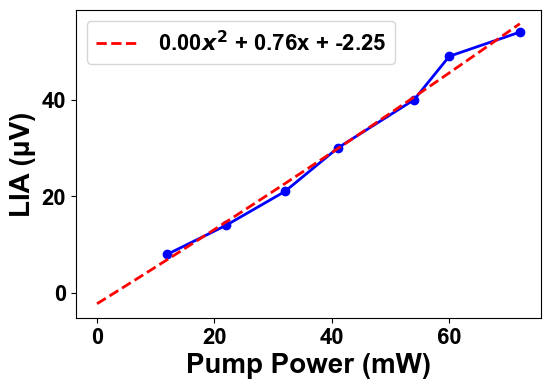

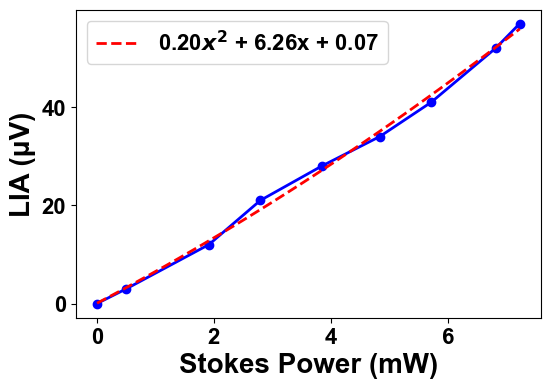

In [27]:
# Pump power
sweep_pump = [72, 60, 54, 41, 32, 22, 12] * u.mW
fixed_stokes = np.full(fill_value=7.22, shape=sweep_pump.shape[0]) * u.mW
lia_pump = [54, 49, 40, 30, 21, 14, 8] * u.uV

# Stokes power
sweep_stokes = [7.22, 6.81, 5.71, 4.83, 3.84, 2.79, 1.91, 0.5, 0] * u.mW
fixed_pump = np.full(fill_value=74, shape=sweep_stokes.shape[0]) * u.mW
lia_stokes = [57, 52, 41, 34, 28, 21, 12, 3, 0] * u.uV

# Polynomial fit
pump_coeff = np.polyfit(sweep_pump.m, lia_pump.m, 2)
stokes_coeff = np.polyfit(sweep_stokes.m, lia_stokes.m, 2)

pump_lia_fun = np.poly1d(pump_coeff)
stokes_lia_fun = np.poly1d(stokes_coeff)

pump_Pinterp = np.linspace(0, np.max(sweep_pump.m), 100)
stokes_Pinterp = np.linspace(0, np.max(sweep_stokes.m), 100)

pump_fit = pump_lia_fun(pump_Pinterp)
stokes_fit = stokes_lia_fun(stokes_Pinterp)




fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(sweep_pump, lia_pump, marker='o', color='blue')
ax.plot(pump_Pinterp, pump_fit, linestyle='--', color='r', label=f'{pump_coeff[0]:.2f}$x^2$ + {pump_coeff[1]:.2f}x + {pump_coeff[2]:.2f}')
ax.set_xlabel("Pump Power (mW)")
ax.set_ylabel("LIA (μV)")
ax.legend() 

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(sweep_stokes, lia_stokes, marker='o', color='blue')
ax.plot(stokes_Pinterp, stokes_fit, linestyle='--', color='r', label=f'{stokes_coeff[0]:.2f}$x^2$ + {stokes_coeff[1]:.2f}x + {stokes_coeff[2]:.2f}')
ax.set_xlabel("Stokes Power (mW)")  
ax.set_ylabel("LIA (μV)")
ax.legend()
plt.show()